In [27]:
# ============================================
# Standard library imports
# ============================================
import re
import sys
import json
import pickle
import logging
import random
import subprocess
import warnings
import collections
from pathlib import Path

from IPython.display import display

warnings.filterwarnings("ignore")


# ============================================
# Numeric / statistics
# ============================================

import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import rankdata


# ============================================
# Plotting / visualization
# ============================================

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

import seaborn as sns


# ============================================
# scikit-learn
# ============================================

from sklearn import model_selection, metrics
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance
from sklearn import __version__ as sklearn_version


# ============================================
# Optimization
# ============================================

import optuna


# ============================================
# LightGBM
# ============================================

try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
except Exception as e:
    raise RuntimeError(
        "LightGBM is not installed. Please install it with `pip install lightgbm`."
    ) from e


# ============================================
# RNA structure
# Later this can be removed if all structure features are precomputed by script.
# ============================================

import RNA


# ============================================
# Model explanation
# ============================================

import shap


# ============================================
# User utilities
# ============================================

import sylib


# ============================================
# Version info
# ============================================

print(f"python    = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas    = {pd.__version__}")
print(f"numpy     = {np.__version__}")
print(f"scipy     = {scipy.__version__}")
print(f"sklearn   = {sklearn_version}")
print(f"optuna    = {optuna.__version__}")
print(f"lightgbm  = {lgb.__version__}")
print(f"ViennaRNA = {RNA.__version__}")
print(f"sylib     = {sylib.__version__}")


# ============================================
# Logging
# ============================================

logging.root.handlers = []

stream_handler = logging.StreamHandler(sys.stderr)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)

logger = logging.getLogger(__name__)

logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("lightgbm").setLevel(logging.WARNING)

python    = 3.11.15
pandas    = 2.3.3
numpy     = 2.4.6
scipy     = 1.17.1
sklearn   = 1.9.0
optuna    = 4.9.0
lightgbm  = 4.6.0
ViennaRNA = 2.7.2
sylib     = 0.3.0.dev0+ae18bb2


In [2]:
# ============================================
# Plotting configuration & helpers
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}

def set_plot_style(
    *,
    font_size=14,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    tight_layout=True,
    fig_w=6.0,
    fig_h=6.0,
):
    """
    Neutral, publication-ready plotting style.
    (based on your original config)
    """
    sns.set_style("ticks")
    mpl.rcParams.update({
        "font.size": font_size,
        "figure.dpi": dpi,
        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,
        "axes.grid": grid,
    })
    _PLOT_CFG.update({"fig_w": fig_w, "fig_h": fig_h, "dpi": dpi})
    if tight_layout:
        plt.rcParams["figure.autolayout"] = False


def make_fig(w=None, h=None, dpi=None):
    """
    Convenience helper using global defaults unless overridden.
    """
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]
    fig, ax = plt.subplots(figsize=(W, H), dpi=D)
    return fig, ax


def _compact_formatter():
    """
    Tick formatter for compact notation (k, M, B).
    """
    def _fmt(x, _pos=None):
        axx = abs(x)
        if axx >= 1e9:
            s = f"{x/1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x/1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x/1e3:.1f}k"
        else:
            s = f"{int(x):d}"
        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )
    return FuncFormatter(_fmt)


def format_axis(ax, *, xlabel=None, ylabel=None, compact_ticks=("x", "y")):
    """
    Apply axis labels and optional compact tick formatting.
    """
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()
    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)
    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)
    return ax


# ============================================
# Joint scatter with KDE marginals
# (your original joint_scatter, generalized)
# ============================================

from matplotlib.gridspec import GridSpec

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    grid = np.linspace(lo, hi, num)
    if len(values) < 2:
        return grid, np.zeros_like(grid)
    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens
    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    """
    Generic joint scatter with top/right KDE marginals.
    Re-usable for any variables (true vs predicted, etc.).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    n = len(x)

    # figure size resolution
    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(figsize=(FW, FH), dpi=(dpi or _PLOT_CFG["dpi"]))

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )
    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    # main scatter
    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    lo -= pad
    hi += pad
    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    # y = x identity line
    if show_identity:
        ax_joint.plot([lo, hi], [lo, hi], ls="--", lw=1.2, color="0.65", zorder=1)

    # regression line
    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(ax_joint, xlabel=xlabel, ylabel=ylabel, compact_ticks=(),)
    if title:
        ax_joint.set_title(title)

    # annotation: Pearson r, n
    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp = np.corrcoef(x, y)[0, 1]
        ax_joint.text(
            0.04,
            0.96,
            rf"$r_p = {rp:.2f}$" + f"\n$n = {n}$",
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    # marginals (KDE normalized)
    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)
    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")
    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()
    return fig, (ax_joint, ax_top, ax_right)

set_plot_style()


In [3]:
# ============================================
# Inspect available raw input files
# ============================================

RAW = Path("../data/raw")

files = sorted(RAW.glob("*.tsv.gz"))

for f in files:
    print(f.name)

AT21.PR_var.N50-TSL0-ARL0.MFE.tsv.gz
AT21.PR_var.N50-TSL0-ARL0.RNA.seq_data.tsv.gz
AT21.PR_var.dev_data.MFE.tsv.gz
AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
NB21.PR_var.N50-TSL0-ARL0.MFE.tsv.gz
NB21.PR_var.N50-TSL0-ARL0.RNA.seq_data.tsv.gz
NB21.PR_var.dev_data.MFE.tsv.gz
NB21.PR_var.dev_data.RNA.seq_data.tsv.gz
OS21.PR_var.N50-TSL0-ARL0.MFE.tsv.gz
OS21.PR_var.N50-TSL0-ARL0.RNA.seq_data.tsv.gz
OS21.PR_var.dev_data.MFE.tsv.gz
OS21.PR_var.dev_data.RNA.seq_data.tsv.gz


In [4]:
# ============================================
# Load sequence data
# ============================================

DATA_DIR = Path("../data/raw")

score_col_name = "PR_var"
group_col_name = None

rna_temp = 22

seq_file = DATA_DIR / "AT21.PR_var.dev_data.RNA.seq_data.tsv.gz"

seq_df, metadata = sylib.fileio.load_df(
    str(seq_file)
)

metadata.print_minimum_data(
    label="Sequence data",
    logger=logger,
    logging_level="info",
)

print(f"Input file : {seq_file.name}")
print(f"Shape      : {seq_df.shape}")

display(seq_df.head())

2026-06-19 00:20:14,334     INFO: Sequence data |   name = AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
2026-06-19 00:20:14,335     INFO: Sequence data |    md5 = 463f63c03bb16bfb05e1f6ea025947b8
2026-06-19 00:20:14,336     INFO: Sequence data | md5_gz = 7940f4f1aa886ba02c249422c074027e


Input file : AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
Shape      : (65, 11)


,var_id,trans_id,gene_id,usage,PR_var,5'UTR,CDS,3'UTR,n_5'UTR_introns,n_CDS_introns,n_3'UTR_introns
0,AT1G07770.2.2409543.2408264,AT1G07770.2,AT1G07770,0.043245,0.408580,CUCUUCUUCCUCUAAUUGCUUUUCUCCGUCACUGAGUACCUUGCCU...,AUGGUAAGAAUCAGUGUUCUUAACGAUGCUCUCAAGAGCAUGUACA...,AGUUUUAUUUUAUGGGGAAACAGAUUUUCAUUGAGUUAUUUUUAAC...,1,2,0
1,AT1G07770.2.2409543.2408265,AT1G07770.2,AT1G07770,0.035668,0.447437,CUCUUCUUCCUCUAAUUGCUUUUCUCCGUCACUGAGUACCUUGCCU...,AUGGUAAGAAUCAGUGUUCUUAACGAUGCUCUCAAGAGCAUGUACA...,AGUUUUAUUUUAUGGGGAAACAGAUUUUCAUUGAGUUAUUUUUAAC...,1,2,0
2,AT1G07770.3.2409543.2408265,AT1G07770.3,AT1G07770,0.037044,0.626719,CUCUUCUUCCUCUAAUUGCUUUUCUCCGUCACUGAGUACCUUGCCU...,AUGGUAAGAAUCAGUGUUCUUAACGAUGCUCUCAAGAGCAUGUACA...,AGUUUUAUUUUAUGGGGAAACAGAUUUUCAUUGAGUUAUUUUUAAC...,1,2,0
3,AT1G07820.1.2421940.2421219,AT1G07820.1,AT1G07820,0.111209,0.522178,GUCAAAUUCAAUUGAUCCUCUCUCCAAAUCAUCUUAAAAGUAUCUU...,AUGUCGGGAAGAGGAAAGGGAGGAAAAGGAUUGGGAAAGGGAGGAG...,UCCGAUUUGGGGGAUUAGGGUUUAUGCAAGUUUGGGGAUUUCUUCU...,0,0,0
4,AT1G07820.2.2421937.2421219,AT1G07820.2,AT1G07820,0.079275,0.490502,AAAUUCAAUUGAUCCUCUCUCCAAAUCAUCUUAAAAUCACAGAUCU...,AUGUCGGGAAGAGGAAAGGGAGGAAAAGGAUUGGGAAAGGGAGGAG...,UCCGAUUUGGGGGAUUAGGGUUUAUGCAAGUUUGGGGAUUUCUUCU...,1,0,0


In [6]:
# ============================================
# Feature Evaluation: Definition of Features
# ============================================

def normalize_rna(seq):
    if pd.isna(seq):
        return ""
    return str(seq).upper().replace("T", "U")


def cat_full_rna(utr5_list, cds_list, utr3_list):
    return [
        normalize_rna(u5) + normalize_rna(cds) + normalize_rna(u3)
        for u5, cds, u3 in zip(utr5_list, cds_list, utr3_list)
    ]


def _all_kmers(k, is_rna=True):
    alphabet = ["A", "U", "G", "C"] if is_rna else ["A", "T", "G", "C"]
    out = []

    def rec(prefix, d):
        if d == 0:
            out.append(prefix)
            return
        for ch in alphabet:
            rec(prefix + ch, d - 1)

    rec("", k)
    return out


def _windows_for_seq(s, win, step):
    s = normalize_rna(s)
    L = len(s)

    if L == 0 or win <= 0:
        return [], []

    starts = list(range(0, max(L - win + 1, 0) + 1, step))
    return [s[i:i + win] for i in starts], starts


def eval_length(seq_list, region_name, logger=logger):
    return pd.DataFrame({
        f"{region_name}.Length": [
            len(normalize_rna(seq))
            for seq in seq_list
        ]
    })


def eval_kmer_freq(seq_list, region_name, is_rna_seq=True, k=1, logger=logger):
    seq_list = [
        normalize_rna(seq)
        for seq in seq_list
    ]

    count_dict = sylib.sequtils.count_nuc_k_mer_of_seq_list(
        seq_list,
        is_rna_seq=is_rna_seq,
        k=k,
    )

    feat_df = pd.DataFrame({
        f"{region_name}.{key}-freq": count_dict[key]
        for key in count_dict
    })

    seq_len_sr = pd.Series([
        len(seq)
        for seq in seq_list
    ])

    seq_len_sr[seq_len_sr == 0] = 1

    for col_name in feat_df.columns:
        feat_df[col_name] /= seq_len_sr
        feat_df[col_name] *= 1000

    return feat_df


def eval_s_freq(seq_list, region_name, logger=logger):
    v = []

    for seq in seq_list:
        seq = normalize_rna(seq)
        value = (seq.count("G") + seq.count("C")) / len(seq) * 1000 if len(seq) > 0 else 0.0
        v.append(value)

    return pd.DataFrame({
        f"{region_name}.S-freq": v
    })


def eval_y_freq(seq_list, region_name, logger=logger):
    v = []

    for seq in seq_list:
        seq = normalize_rna(seq)
        value = (seq.count("U") + seq.count("C")) / len(seq) * 1000 if len(seq) > 0 else 0.0
        v.append(value)

    return pd.DataFrame({
        f"{region_name}.Y-freq": v
    })


def eval_k_freq(seq_list, region_name, logger=logger):
    v = []

    for seq in seq_list:
        seq = normalize_rna(seq)
        value = (seq.count("G") + seq.count("U")) / len(seq) * 1000 if len(seq) > 0 else 0.0
        v.append(value)

    return pd.DataFrame({
        f"{region_name}.K-freq": v
    })


def eval_n_uaug(utr5_seq_list, region_name, is_rna_seq=True, logger=logger):
    seq_list = [
        normalize_rna(seq)
        for seq in utr5_seq_list
    ]

    if is_rna_seq:
        return pd.DataFrame({
            f"{region_name}.uAUG": [
                seq.count("AUG")
                for seq in seq_list
            ]
        })

    return pd.DataFrame({
        f"{region_name}.uATG": [
            seq.replace("U", "T").count("ATG")
            for seq in seq_list
        ]
    })


def eval_n_uorf(utr5_seq_list, region_name, is_rna_seq=True, logger=logger):
    feat_df_dict = {
        f"{region_name}.uORF-NO": [],
        f"{region_name}.uORF-IO": [],
        f"{region_name}.uORF-OO": [],
    }

    start_codon = "AUG" if is_rna_seq else "ATG"
    stop_codons = {"UAA", "UGA", "UAG"} if is_rna_seq else {"TAA", "TGA", "TAG"}

    for seq in utr5_seq_list:
        seq = normalize_rna(seq)
        if not is_rna_seq:
            seq = seq.replace("U", "T")

        L = len(seq)
        n_no = n_io = n_oo = 0

        for i in range(L - 2):
            if seq[i:i + 3] == start_codon:
                has_stop = False

                for j in range(i + 3, L - 2, 3):
                    if seq[j:j + 3] in stop_codons:
                        has_stop = True
                        break

                if has_stop:
                    n_no += 1
                elif (L - i) % 3 == 0:
                    n_io += 1
                else:
                    n_oo += 1

        feat_df_dict[f"{region_name}.uORF-NO"].append(n_no)
        feat_df_dict[f"{region_name}.uORF-IO"].append(n_io)
        feat_df_dict[f"{region_name}.uORF-OO"].append(n_oo)

    return pd.DataFrame(feat_df_dict)


def eval_n_daug(utr3_seq_list, region_name, is_rna_seq=True, logger=logger):
    seq_list = [
        normalize_rna(seq)
        for seq in utr3_seq_list
    ]

    if is_rna_seq:
        return pd.DataFrame({
            f"{region_name}.dAUG": [
                seq.count("AUG")
                for seq in seq_list
            ]
        })

    return pd.DataFrame({
        f"{region_name}.dATG": [
            seq.replace("U", "T").count("ATG")
            for seq in seq_list
        ]
    })


def eval_n_dorf(utr3_seq_list, region_name, is_rna_seq=True, logger=logger):
    feat_df_dict = {
        f"{region_name}.dORF": [],
        f"{region_name}.dORF-NS": [],
    }

    start_codon = "AUG" if is_rna_seq else "ATG"
    stop_codons = {"UAA", "UGA", "UAG"} if is_rna_seq else {"TAA", "TGA", "TAG"}

    for seq in utr3_seq_list:
        seq = normalize_rna(seq)
        if not is_rna_seq:
            seq = seq.replace("U", "T")

        seq = seq + "AA"
        L = len(seq)

        n_no = 0
        n_ns = 0

        for i in range(L - 2):
            if seq[i:i + 3] == start_codon:
                has_stop = False

                for j in range(i + 3, L - 2, 3):
                    if seq[j:j + 3] in stop_codons:
                        has_stop = True
                        break

                if has_stop:
                    n_no += 1
                else:
                    n_ns += 1

        feat_df_dict[f"{region_name}.dORF"].append(n_no)
        feat_df_dict[f"{region_name}.dORF-NS"].append(n_ns)

    return pd.DataFrame(feat_df_dict)


def eval_codon_usage(
    cds_seq_list,
    region_name,
    is_rna_seq=True,
    should_remove_stop_codons=True,
    logger=logger,
):
    cds_seq_list = [
        normalize_rna(seq)
        for seq in cds_seq_list
    ]

    if not is_rna_seq:
        cds_seq_list = [
            seq.replace("U", "T")
            for seq in cds_seq_list
        ]

    mer3_list = sylib.sequtils.get_k_mer_nuc_list(
        3,
        is_rna_seq=is_rna_seq,
    )

    aa_codon_dict = sylib.sequtils.get_aa_codon_dict(
        is_rna_seq=is_rna_seq,
        code_type="3-letter",
    )

    n_codons_dict = {
        mer3: [0] * len(cds_seq_list)
        for mer3 in mer3_list
    }

    for i, cds_seq in enumerate(cds_seq_list):
        for j in range(0, len(cds_seq) - 2, 3):
            codon = cds_seq[j:j + 3]
            if codon in n_codons_dict:
                n_codons_dict[codon][i] += 1

    codons_df = pd.DataFrame(n_codons_dict)

    usage_df_dict = {}

    for aa, codon_list in aa_codon_dict.items():
        aa_sr = pd.Series([0] * len(cds_seq_list))

        for codon in codon_list:
            aa_sr += codons_df[codon]

        aa_sr[aa_sr == 0] = 1

        for codon in codon_list:
            key = f"{region_name}.{aa}-{codon}"
            usage_df_dict[key] = (codons_df[codon] / aa_sr) * 1000

    if is_rna_seq:
        usage_df_dict.pop(f"{region_name}.Met-AUG", None)
        usage_df_dict.pop(f"{region_name}.Trp-UGG", None)

        if should_remove_stop_codons:
            for c in ("UAA", "UGA", "UAG"):
                usage_df_dict.pop(f"{region_name}.Ter-{c}", None)
    else:
        usage_df_dict.pop(f"{region_name}.Met-ATG", None)
        usage_df_dict.pop(f"{region_name}.Trp-TGG", None)

        if should_remove_stop_codons:
            for c in ("TAA", "TGA", "TAG"):
                usage_df_dict.pop(f"{region_name}.Ter-{c}", None)

    return pd.DataFrame(usage_df_dict)


def wobble_freq(cds_list, region_label="CDS"):
    alphabet = ["A", "U", "G", "C"]

    cols = {
        f"{region_label}.wobble_pct_{b}": []
        for b in alphabet
    }

    for s in cds_list:
        s = normalize_rna(s)

        wob = [
            s[i]
            for i in range(2, len(s), 3)
            if i < len(s)
        ]

        total = len(wob)

        for b in alphabet:
            cols[f"{region_label}.wobble_pct_{b}"].append(
                (wob.count(b) / total) if total > 0 else 0.0
            )

    return pd.DataFrame(cols)


CODON_TO_AA_RNA = {
    "UUU": "F", "UUC": "F", "UUA": "L", "UUG": "L",
    "UCU": "S", "UCC": "S", "UCA": "S", "UCG": "S",
    "UAU": "Y", "UAC": "Y", "UAA": "X", "UAG": "X",
    "UGU": "C", "UGC": "C", "UGA": "X", "UGG": "W",
    "CUU": "L", "CUC": "L", "CUA": "L", "CUG": "L",
    "CCU": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "CAU": "H", "CAC": "H", "CAA": "Q", "CAG": "Q",
    "CGU": "R", "CGC": "R", "CGA": "R", "CGG": "R",
    "AUU": "I", "AUC": "I", "AUA": "I", "AUG": "M",
    "ACU": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    "AAU": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "AGU": "S", "AGC": "S", "AGA": "R", "AGG": "R",
    "GUU": "V", "GUC": "V", "GUA": "V", "GUG": "V",
    "GCU": "A", "GCC": "A", "GCA": "A", "GCG": "A",
    "GAU": "D", "GAC": "D", "GAA": "E", "GAG": "E",
    "GGU": "G", "GGC": "G", "GGA": "G", "GGG": "G",
}

AA_LIST = sorted(set(CODON_TO_AA_RNA.values()))


def aa_freq_from_cds(cds_list, region_label="CDS"):
    cols = {
        f"{region_label}.aa_pct_{aa}": []
        for aa in AA_LIST
    }

    for s in cds_list:
        s = normalize_rna(s)

        cnts = {
            aa: 0
            for aa in AA_LIST
        }

        total = 0

        for i in range(0, len(s) - 2, 3):
            aa = CODON_TO_AA_RNA.get(s[i:i + 3])

            if aa is None:
                continue

            cnts[aa] += 1
            total += 1

        for aa in AA_LIST:
            cols[f"{region_label}.aa_pct_{aa}"].append(
                (cnts[aa] / total) if total > 0 else 0.0
            )

    return pd.DataFrame(cols)


DICODONS_DNA = [
    "AGGCGA", "AGGCGG", "ATACGA", "ATACGG", "CGAATA",
    "CGACCG", "CGACGA", "CGACGG", "CGACTG", "CGAGCG",
    "CTCATA", "CTCCCG", "CTGATA", "CTGCCG", "CTGCGA",
    "CTGCTG", "CTTCTG", "GTACCG", "GTACGA", "GTGCGA",
]

DICODONS_RNA = [
    d.replace("T", "U")
    for d in DICODONS_DNA
]


def dicodon_counts_rna(cds_list, region_label="CDS", normalized=True):
    cols = {
        f"{region_label}.dicodon_{d}": []
        for d in DICODONS_RNA
    }

    for s in cds_list:
        s = normalize_rna(s)

        counts = {
            d: 0
            for d in DICODONS_RNA
        }

        total = 0

        for i in range(0, len(s) - 5, 3):
            six = s[i:i + 6]

            if len(six) == 6:
                total += 1

                if six in counts:
                    counts[six] += 1

        for d in DICODONS_RNA:
            v = (counts[d] / total) if (normalized and total > 0) else counts[d]
            cols[f"{region_label}.dicodon_{d}"].append(v)

    return pd.DataFrame(cols)

In [7]:
# ============================================
# Feature Evaluation: Execution of Feature Functions
# ============================================

def build_non_structure_features(df):
    parts = []

    # 1. Region lengths
    parts += [
        eval_length(df["5'UTR"], "5'UTR"),
        eval_length(df["CDS"],   "CDS"),
        eval_length(df["3'UTR"], "3'UTR"),
    ]

    # 2. Region-level k-mer frequencies
    for k in [1, 2, 3]:
        parts += [
            eval_kmer_freq(df["5'UTR"], "5'UTR", is_rna_seq=True, k=k),
            eval_kmer_freq(df["CDS"],   "CDS",   is_rna_seq=True, k=k),
            eval_kmer_freq(df["3'UTR"], "3'UTR", is_rna_seq=True, k=k),
        ]

    # 3. Degenerate nucleotide class frequencies
    parts += [
        eval_s_freq(df["5'UTR"], "5'UTR"),
        eval_y_freq(df["5'UTR"], "5'UTR"),
        eval_k_freq(df["5'UTR"], "5'UTR"),

        eval_s_freq(df["3'UTR"], "3'UTR"),
        eval_y_freq(df["3'UTR"], "3'UTR"),
        eval_k_freq(df["3'UTR"], "3'UTR"),
    ]

    # 4. Upstream/downstream ORF features
    parts += [
        eval_n_uaug(df["5'UTR"], "5'UTR", is_rna_seq=True),
        eval_n_uorf(df["5'UTR"], "5'UTR", is_rna_seq=True),

        eval_n_daug(df["3'UTR"], "3'UTR", is_rna_seq=True),
        eval_n_dorf(df["3'UTR"], "3'UTR", is_rna_seq=True),
    ]

    # 5. CDS coding features
    parts += [
        eval_codon_usage(
            df["CDS"],
            "CDS",
            is_rna_seq=True,
            should_remove_stop_codons=True,
        ),
        wobble_freq(df["CDS"], "CDS"),
        aa_freq_from_cds(df["CDS"], "CDS"),
        dicodon_counts_rna(df["CDS"], "CDS", normalized=True),
    ]

    x_feat_df = pd.concat(parts, axis=1)

    return x_feat_df


x_non_structure_df = build_non_structure_features(seq_df)

print("non-structure feature matrix:", x_non_structure_df.shape)
display(x_non_structure_df.head())

non-structure feature matrix: (65, 372)


,5'UTR.Length,CDS.Length,3'UTR.Length,5'UTR.A-freq,5'UTR.U-freq,5'UTR.G-freq,5'UTR.C-freq,CDS.A-freq,CDS.U-freq,CDS.G-freq,...,CDS.dicodon_CUCAUA,CDS.dicodon_CUCCCG,CDS.dicodon_CUGAUA,CDS.dicodon_CUGCCG,CDS.dicodon_CUGCGA,CDS.dicodon_CUGCUG,CDS.dicodon_CUUCUG,CDS.dicodon_GUACCG,CDS.dicodon_GUACGA,CDS.dicodon_GUGCGA
0,86,393,149,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,86,393,148,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,89,393,148,202.247191,337.078652,179.775281,280.898876,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,195,312,216,251.282051,405.128205,143.589744,200.000000,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,73,312,216,356.164384,315.068493,136.986301,191.780822,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
x_non_structure_df = build_non_structure_features(seq_df)

print("non-structure feature matrix:", x_non_structure_df.shape)
print("missing values:", x_non_structure_df.isna().sum().sum())
print("infinite values:", np.isinf(x_non_structure_df.to_numpy()).sum())
print("duplicated columns:", x_non_structure_df.columns.duplicated().sum())

display(x_non_structure_df.head())

non-structure feature matrix: (65, 372)
missing values: 0
infinite values: 0
duplicated columns: 0


,5'UTR.Length,CDS.Length,3'UTR.Length,5'UTR.A-freq,5'UTR.U-freq,5'UTR.G-freq,5'UTR.C-freq,CDS.A-freq,CDS.U-freq,CDS.G-freq,...,CDS.dicodon_CUCAUA,CDS.dicodon_CUCCCG,CDS.dicodon_CUGAUA,CDS.dicodon_CUGCCG,CDS.dicodon_CUGCGA,CDS.dicodon_CUGCUG,CDS.dicodon_CUUCUG,CDS.dicodon_GUACCG,CDS.dicodon_GUACGA,CDS.dicodon_GUGCGA
0,86,393,149,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,86,393,148,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,89,393,148,202.247191,337.078652,179.775281,280.898876,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,195,312,216,251.282051,405.128205,143.589744,200.000000,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,73,312,216,356.164384,315.068493,136.986301,191.780822,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# ============================================
# Structure precompute wrapper
# ============================================

FEATURE_DIR = Path("../results/features")
FEATURE_DIR.mkdir(parents=True, exist_ok=True)


def get_structure_file_path(seq_file):
    seq_file = Path(seq_file)

    return FEATURE_DIR / seq_file.name.replace(
        ".RNA.seq_data.tsv.gz",
        ".structure.tsv.gz",
    )

def ensure_structure_file(
    seq_file,
    rna_temp,
    n_workers=10,
    force=False,
):
    seq_file = Path(seq_file)
    structure_file = get_structure_file_path(seq_file)

    if structure_file.exists() and not force:
        logger.info("Structure file already exists: %s", structure_file)
        return structure_file

    cmd = [
        sys.executable,
        "../scripts/precompute_mfe.py",
        str(seq_file),
        str(structure_file),
        "--temperature",
        str(rna_temp),
        "-p",
        str(n_workers),
    ]

    if force:
        cmd.append("--force")

    logger.info("Running structure script:")
    logger.info(" ".join(cmd))

    subprocess.run(cmd, check=True)

    return structure_file

In [ ]:
# ============================================
# Load structure features
# ============================================

structure_file = ensure_structure_file(
    seq_file=seq_file,
    rna_temp=rna_temp,
    n_workers=10,
    force=False,
)

structure_df, metadata = sylib.fileio.load_df(
    str(structure_file)
)

metadata.print_minimum_data(
    label="Structure features",
    logger=logger,
    logging_level="info",
)

print(f"Structure file : {structure_file.name}")
print(f"Shape          : {structure_df.shape}")

display(structure_df.head())

2026-06-19 00:28:08,421     INFO: Running structure script:
2026-06-19 00:28:08,422     INFO: /home/ha-ibnu/miniconda3/envs/ibnu/bin/python ../scripts/precompute_mfe.py ../data/raw/AT21.PR_var.dev_data.RNA.seq_data.tsv.gz ../results/features/AT21.PR_var.dev_data.structure.tsv.gz --temperature 22 -p 10 --force
2026-06-19 00:28:10,806     INFO: loading input: ../data/raw/AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
2026-06-19 00:28:10,817     INFO: Input data |   name = AT21.PR_var.dev_data.RNA.seq_data.tsv.gz
2026-06-19 00:28:10,817     INFO: Input data |    md5 = 463f63c03bb16bfb05e1f6ea025947b8
2026-06-19 00:28:10,817     INFO: Input data | md5_gz = 7940f4f1aa886ba02c249422c074027e
2026-06-19 00:28:10,817     INFO: calculating MFE.5'UTR
2026-06-19 00:28:10,885     INFO: completed 65 / 65
2026-06-19 00:28:10,892     INFO: calculating MFE.CDS
2026-06-19 00:28:12,132     INFO: completed 65 / 65
2026-06-19 00:28:12,140     INFO: calculating MFE.3'UTR
2026-06-19 00:28:12,329     INFO: complete

Structure file : AT21.PR_var.dev_data.structure.tsv.gz
Shape          : (65, 7)


,var_id,trans_id,gene_id,MFE.5'UTR,MFE.CDS,MFE.3'UTR,MFE.mRNA
0,AT1G07770.2.2409543.2408264,AT1G07770.2,AT1G07770,-28.57,-160.449997,-39.34,-242.389999
1,AT1G07770.2.2409543.2408265,AT1G07770.2,AT1G07770,-28.57,-160.449997,-39.34,-242.389999
2,AT1G07770.3.2409543.2408265,AT1G07770.3,AT1G07770,-30.15,-160.449997,-39.34,-243.250000
3,AT1G07820.1.2421940.2421219,AT1G07820.1,AT1G07820,-45.48,-122.290001,-57.73,-265.089996
4,AT1G07820.2.2421937.2421219,AT1G07820.2,AT1G07820,-10.29,-122.290001,-57.73,-217.289993


In [16]:
# ============================================
# Combine non-structure and structure features
# ============================================

id_cols = [
    col for col in ["var_id", "trans_id", "gene_id"]
    if col in structure_df.columns
]

if "var_id" in seq_df.columns and "var_id" in structure_df.columns:
    assert (seq_df["var_id"].values == structure_df["var_id"].values).all()

x_structure_df = structure_df.drop(columns=id_cols)

x_feat_df = pd.concat(
    [
        x_non_structure_df.reset_index(drop=True),
        x_structure_df.reset_index(drop=True),
    ],
    axis=1,
)

print("complete feature matrix:", x_feat_df.shape)
print("missing values:", x_feat_df.isna().sum().sum())
print("infinite values:", np.isinf(x_feat_df.to_numpy()).sum())
print("duplicated columns:", x_feat_df.columns.duplicated().sum())

display(x_feat_df.head())

complete feature matrix: (65, 376)
missing values: 0
infinite values: 0
duplicated columns: 0


,5'UTR.Length,CDS.Length,3'UTR.Length,5'UTR.A-freq,5'UTR.U-freq,5'UTR.G-freq,5'UTR.C-freq,CDS.A-freq,CDS.U-freq,CDS.G-freq,...,CDS.dicodon_CUGCGA,CDS.dicodon_CUGCUG,CDS.dicodon_CUUCUG,CDS.dicodon_GUACCG,CDS.dicodon_GUACGA,CDS.dicodon_GUGCGA,MFE.5'UTR,MFE.CDS,MFE.3'UTR,MFE.mRNA
0,86,393,149,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,-28.57,-160.449997,-39.34,-242.389999
1,86,393,148,197.674419,337.209302,174.418605,290.697674,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,-28.57,-160.449997,-39.34,-242.389999
2,89,393,148,202.247191,337.078652,179.775281,280.898876,264.631043,284.987277,272.264631,...,0.0,0.0,0.0,0.0,0.0,0.0,-30.15,-160.449997,-39.34,-243.250000
3,195,312,216,251.282051,405.128205,143.589744,200.000000,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,-45.48,-122.290001,-57.73,-265.089996
4,73,312,216,356.164384,315.068493,136.986301,191.780822,272.435897,214.743590,314.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,-10.29,-122.290001,-57.73,-217.289993


In [17]:
# ============================================
# Train/test split
# ============================================

test_data_ratio = 0.20

y_array = np.asarray(seq_df[score_col_name])

if group_col_name is None:
    n_data = len(seq_df)
    n_test = int(round(n_data * test_data_ratio))

    train_idx_array, test_idx_array = model_selection.train_test_split(
        np.arange(n_data),
        random_state=0,
        test_size=n_test,
    )

    g_train, g_test = None, None

    logger.info(
        "n_data = %s, n_train = %s, n_test = %s",
        n_data,
        len(train_idx_array),
        len(test_idx_array),
    )

else:
    g_sr = seq_df[group_col_name]

    gss = model_selection.GroupShuffleSplit(
        n_splits=1,
        test_size=test_data_ratio,
        random_state=0,
    )

    train_idx_array, test_idx_array = list(
        gss.split(np.arange(len(g_sr)), groups=g_sr)
    )[0]

    g_train = g_sr.iloc[train_idx_array].copy()
    g_test = g_sr.iloc[test_idx_array].copy()

    logger.info(
        "n_data = %s (%s groups), n_train = %s (%s groups), n_test = %s (%s groups)",
        len(g_sr),
        len(set(g_sr)),
        len(g_train),
        len(set(g_train)),
        len(g_test),
        len(set(g_test)),
    )

y_train = y_array[train_idx_array].copy()
y_test = y_array[test_idx_array].copy()

x_train = x_feat_df.iloc[train_idx_array, :].copy()
x_test = x_feat_df.iloc[test_idx_array, :].copy()

is_xformed = False

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

2026-06-19 00:29:00,932     INFO: n_data = 65, n_train = 52, n_test = 13


x_train: (52, 376)
x_test : (13, 376)
y_train: (52,)
y_test : (13,)


2026-06-19 00:29:05,377     INFO: Number of PR_var outliers in training data = 0
2026-06-19 00:29:05,378     INFO: Number of PR_var outliers in test data     = 2
2026-06-19 00:29:05,386     INFO: Number of 5'UTR.Length outliers in training data = 1
2026-06-19 00:29:05,386     INFO: Number of 5'UTR.Length outliers in test data     = 0
2026-06-19 00:29:05,392     INFO: Number of CDS.Length outliers in training data = 1
2026-06-19 00:29:05,393     INFO: Number of CDS.Length outliers in test data     = 1
2026-06-19 00:29:05,400     INFO: Number of 3'UTR.Length outliers in training data = 1
2026-06-19 00:29:05,400     INFO: Number of 3'UTR.Length outliers in test data     = 0
2026-06-19 00:29:05,401     INFO: Number of all outliers in training data = 3
2026-06-19 00:29:05,401     INFO: Number of all outliers in test data     = 3


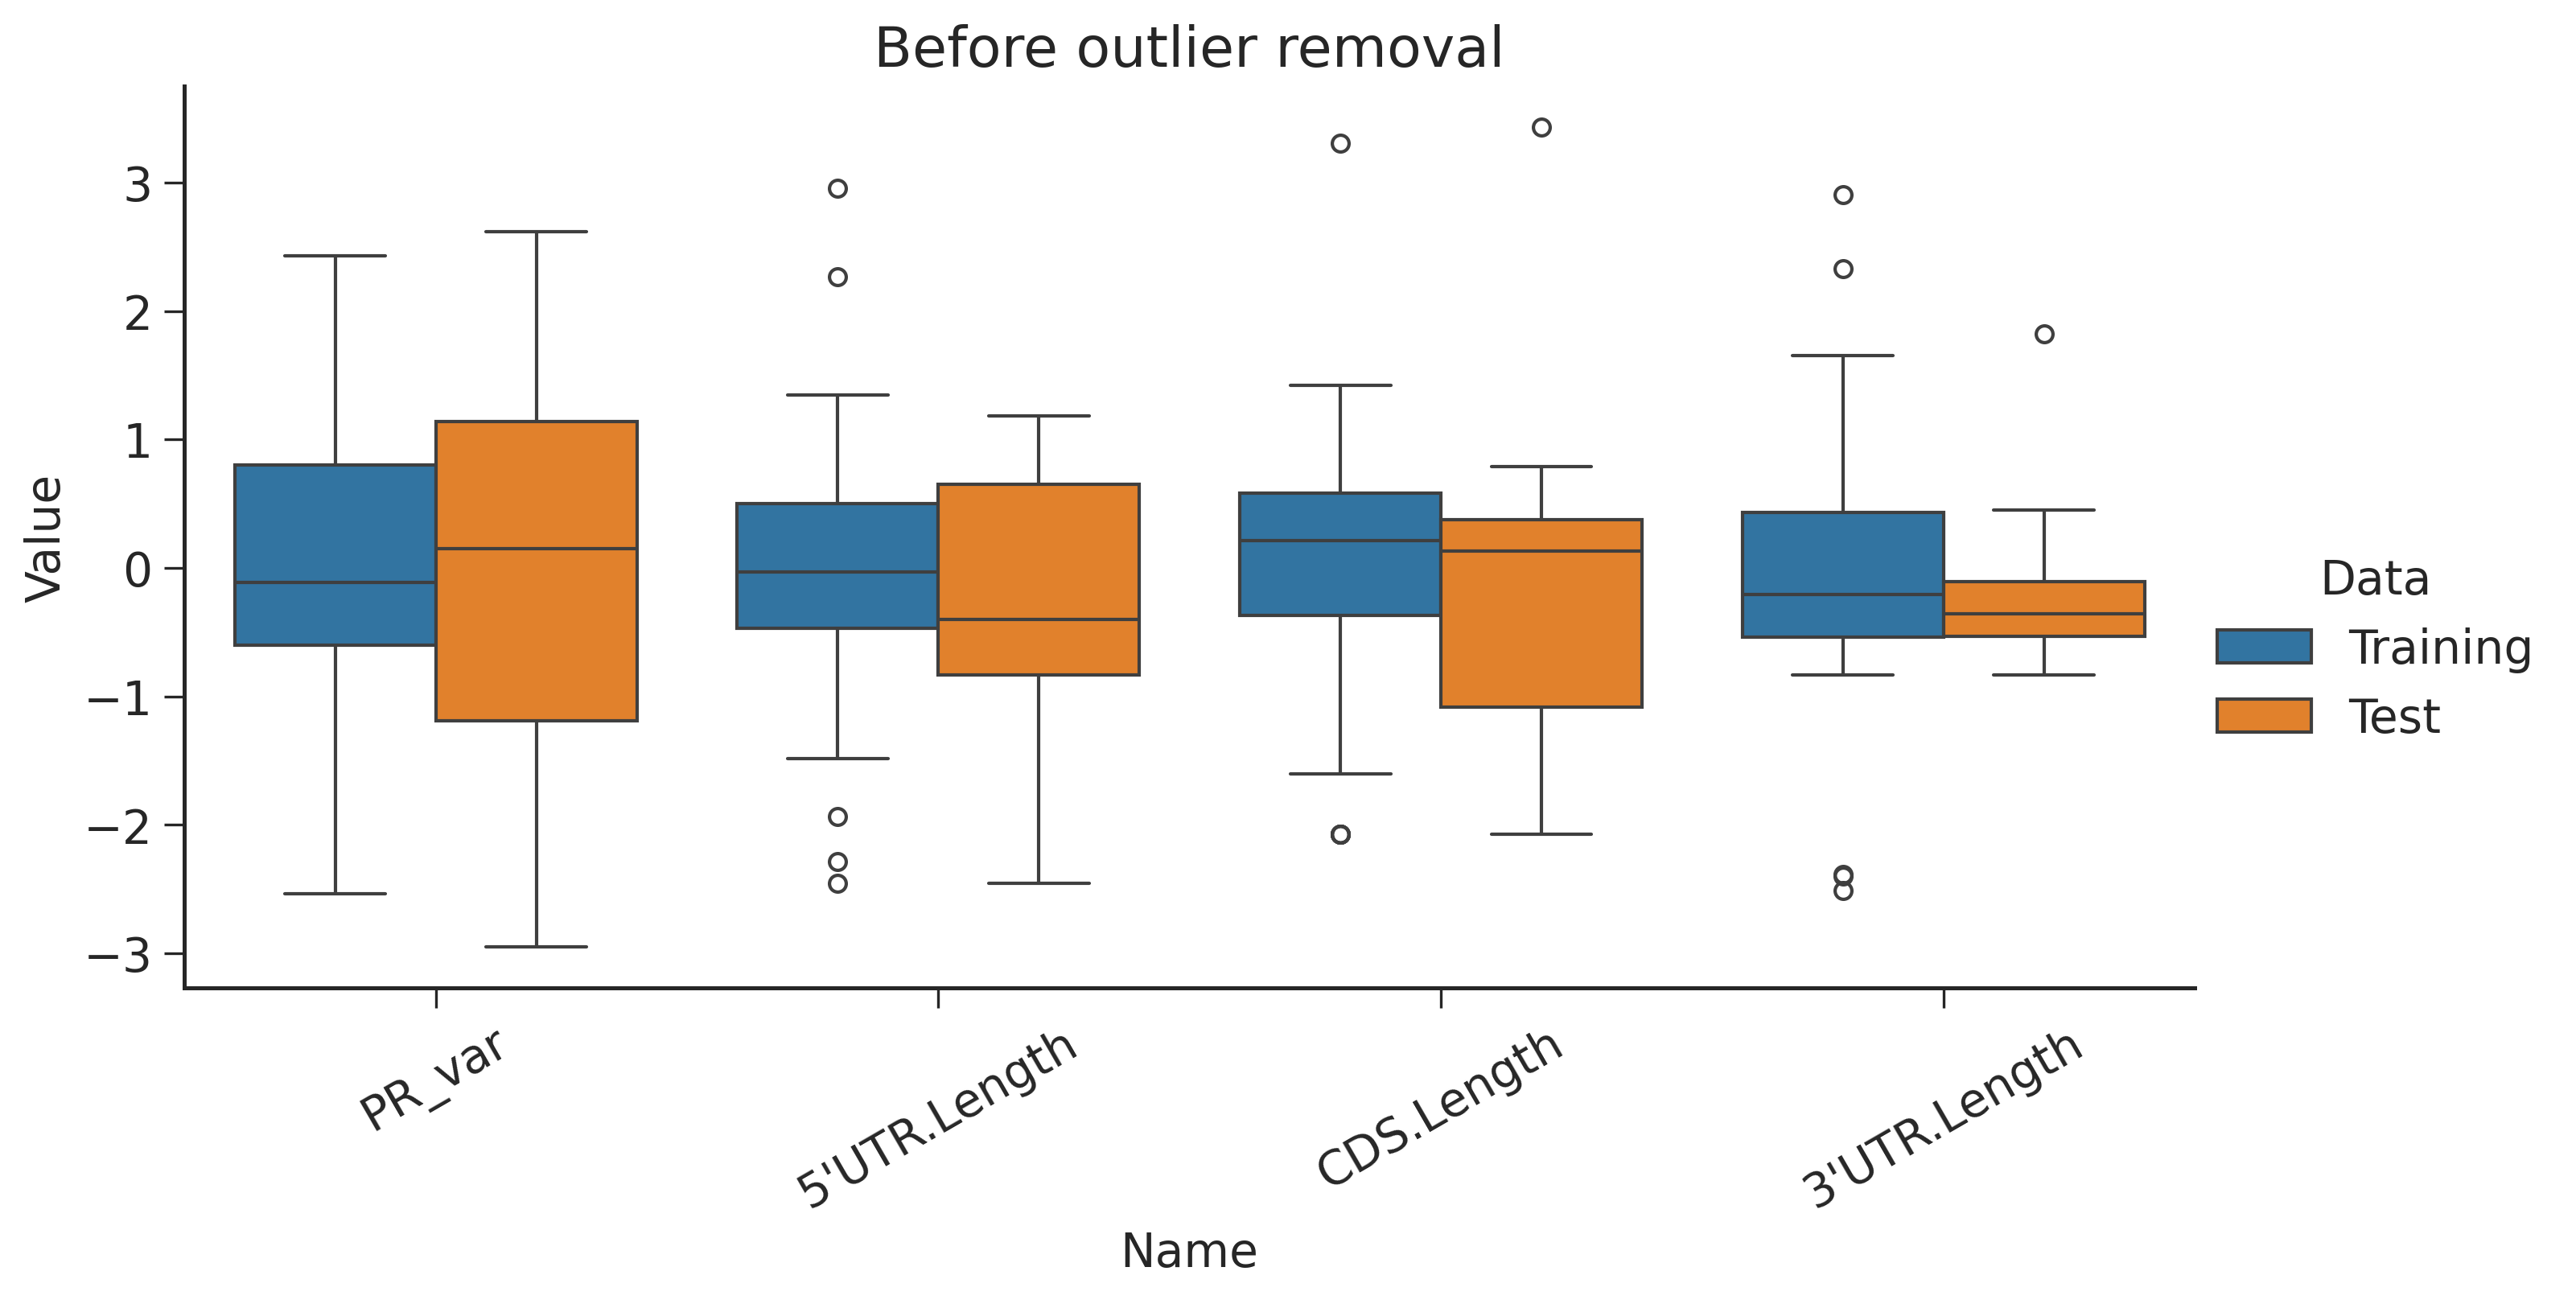

2026-06-19 00:29:05,965  WARNING: The ratio of `0.0` in `5'UTR.AAC-freq` is greater than 50% (53.06%).
2026-06-19 00:29:05,971  WARNING: The ratio of `0.0` in `5'UTR.AUA-freq` is greater than 50% (57.14%).
2026-06-19 00:29:05,982  WARNING: The ratio of `0.0` in `5'UTR.AUG-freq` is greater than 90% (95.92%).
2026-06-19 00:29:05,998  WARNING: The ratio of `0.0` in `5'UTR.AGU-freq` is greater than 50% (57.14%).
2026-06-19 00:29:06,003  WARNING: The ratio of `0.0` in `5'UTR.AGG-freq` is greater than 50% (63.27%).
2026-06-19 00:29:06,013  WARNING: The ratio of `0.0` in `5'UTR.ACA-freq` is greater than 50% (59.18%).
2026-06-19 00:29:06,019  WARNING: The ratio of `0.0` in `5'UTR.ACU-freq` is greater than 50% (51.02%).
2026-06-19 00:29:06,023  WARNING: The ratio of `0.0` in `5'UTR.ACG-freq` is greater than 50% (71.43%).
2026-06-19 00:29:06,029  WARNING: The ratio of `0.0` in `5'UTR.ACC-freq` is greater than 50% (51.02%).
2026-06-19 00:29:06,040  WARNING: The ratio of `0.0` in `5'UTR.UAU-freq` 

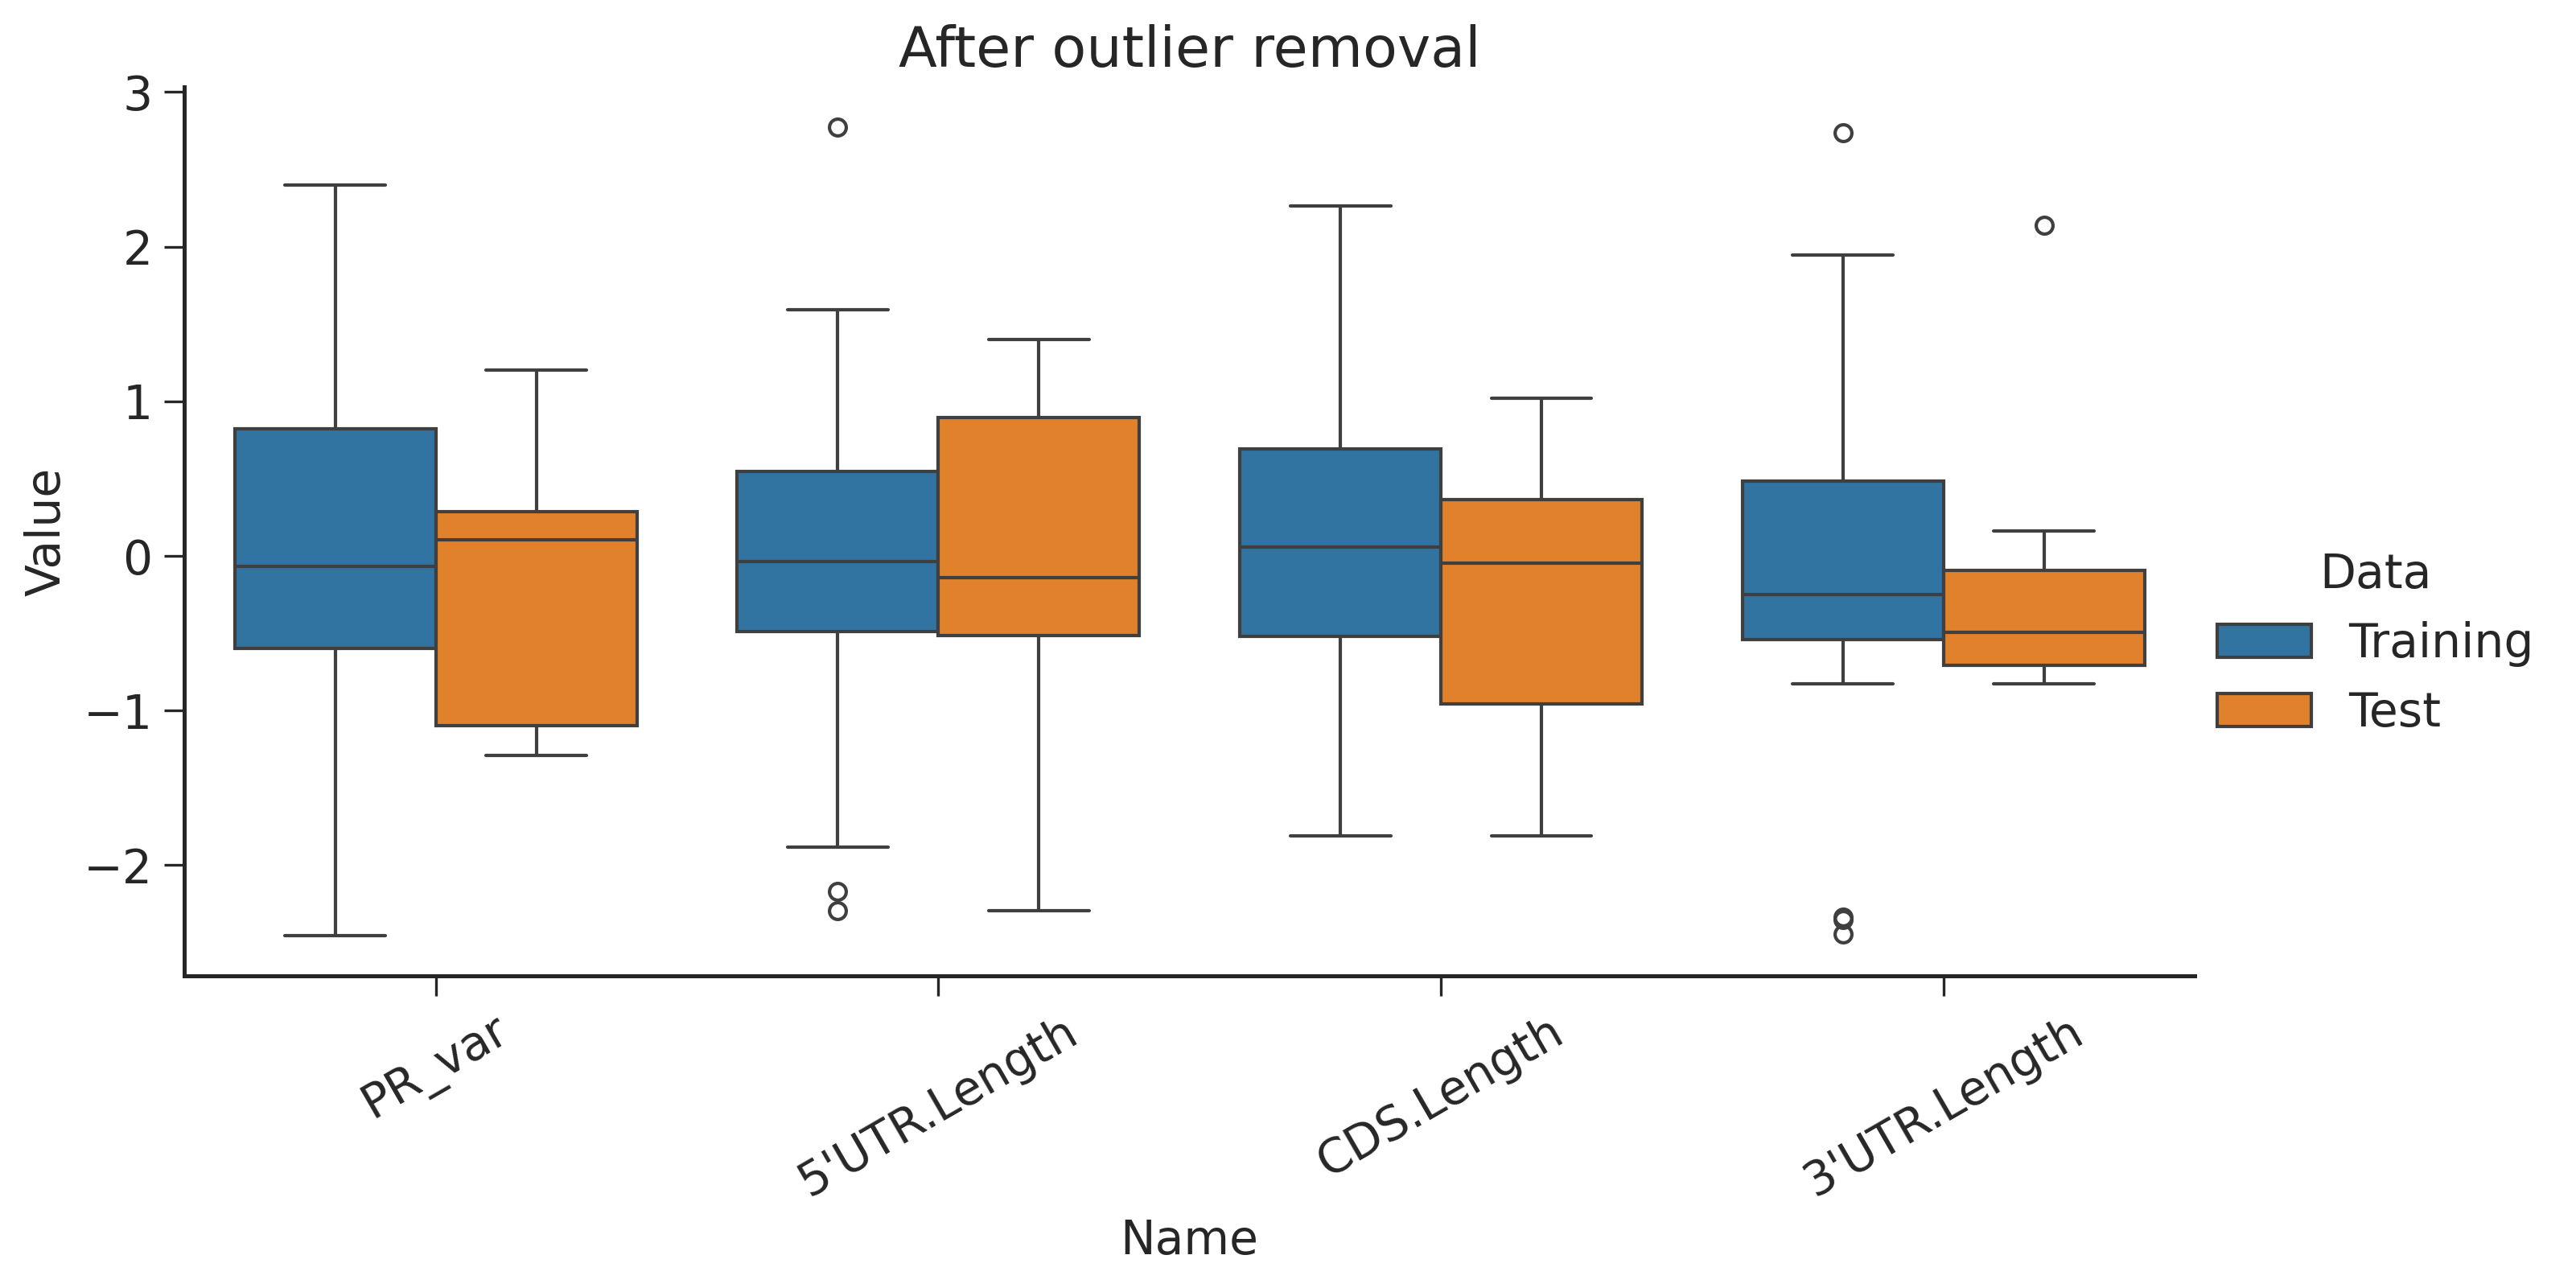

x_train: (49, 361)
x_test : (10, 361)
y_train: (49,)
y_test : (10,)


In [18]:
# ============================================
# Outlier removal and feature transformation
# ============================================

xform_method = "yeo-johnson"

# outlier_removal_method = None
outlier_removal_method = "Z-score"
# outlier_removal_method = "LOF"

z_score_expected_n = 0.5
lof_contamination = "auto"

outlier_det_col_list = [
    "5'UTR.Length",
    "CDS.Length",
    "3'UTR.Length",
]

if is_xformed:
    raise Exception(
        "Data has already been transformed. "
        "If you want to reconvert, restart from the train/test split."
    )


def detect_outliers(
    xformed_train_array,
    xformed_test_array,
    removal_method,
    z_score_expected_n=0.5,
    lof_contamination="auto",
):
    if removal_method is None:
        train_bool_array = np.ones(len(xformed_train_array), dtype=bool)
        test_bool_array = np.ones(len(xformed_test_array), dtype=bool)

    elif removal_method == "Z-score":
        min_thresh = stats.norm.ppf(
            (z_score_expected_n / 2) / len(xformed_train_array),
            loc=0,
            scale=1,
        )
        max_thresh = -min_thresh

        train_bool_array = (
            (xformed_train_array >= min_thresh)
            & (xformed_train_array <= max_thresh)
        )
        test_bool_array = (
            (xformed_test_array >= min_thresh)
            & (xformed_test_array <= max_thresh)
        )

    elif removal_method == "LOF":
        clf = LocalOutlierFactor(
            novelty=True,
            contamination=lof_contamination,
        ).fit(xformed_train_array.reshape(-1, 1))

        train_bool_array = clf.predict(
            xformed_train_array.reshape(-1, 1)
        ) == 1

        test_bool_array = clf.predict(
            xformed_test_array.reshape(-1, 1)
        ) == 1

    else:
        raise ValueError(f"Unknown outlier removal method: {removal_method}")

    return train_bool_array, test_bool_array


# ============================================
# Pre-transform y for outlier detection
# ============================================

pre_y_train, y_xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
    y_train,
    xform_method=xform_method,
    should_stdzn=True,
)

pre_y_test = sylib.utils.xform_array(
    y_test,
    **y_xform_kwargs,
)

temp_df_dict = {
    "Name": [score_col_name] * (len(y_train) + len(y_test)),
    "Data": ["Training"] * len(y_train) + ["Test"] * len(y_test),
    "Value": list(pre_y_train) + list(pre_y_test),
}


# ============================================
# Detect outliers from y
# ============================================

train_bool_array, test_bool_array = detect_outliers(
    pre_y_train,
    pre_y_test,
    outlier_removal_method,
    z_score_expected_n=z_score_expected_n,
    lof_contamination=lof_contamination,
)

logger.info(
    "Number of %s outliers in training data = %s",
    score_col_name,
    len(y_train) - sum(train_bool_array),
)

logger.info(
    "Number of %s outliers in test data     = %s",
    score_col_name,
    len(y_test) - sum(test_bool_array),
)


# ============================================
# Detect outliers from selected feature columns
# ============================================

if len(outlier_det_col_list) > 0:
    for col_name in outlier_det_col_list:

        if col_name not in x_train.columns:
            logger.warning("%s was skipped because it is not in x_train.", col_name)
            continue

        if x_train[col_name].var() == 0:
            continue

        xformed_train_array, xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
            x_train[col_name],
            xform_method=xform_method,
            should_stdzn=True,
        )

        xformed_test_array = sylib.utils.xform_array(
            x_test[col_name],
            **xform_kwargs,
        )

        temp_train_bool_array, temp_test_bool_array = detect_outliers(
            xformed_train_array,
            xformed_test_array,
            outlier_removal_method,
            z_score_expected_n=z_score_expected_n,
            lof_contamination=lof_contamination,
        )

        temp_df_dict["Name"] += [col_name] * (len(y_train) + len(y_test))
        temp_df_dict["Data"] += ["Training"] * len(y_train) + ["Test"] * len(y_test)
        temp_df_dict["Value"] += list(xformed_train_array) + list(xformed_test_array)

        logger.info(
            "Number of %s outliers in training data = %s",
            col_name,
            len(y_train) - sum(temp_train_bool_array),
        )

        logger.info(
            "Number of %s outliers in test data     = %s",
            col_name,
            len(y_test) - sum(temp_test_bool_array),
        )

        train_bool_array &= temp_train_bool_array
        test_bool_array &= temp_test_bool_array

    logger.info(
        "Number of all outliers in training data = %s",
        len(y_train) - sum(train_bool_array),
    )

    logger.info(
        "Number of all outliers in test data     = %s",
        len(y_test) - sum(test_bool_array),
    )


# ============================================
# Plot before outlier removal
# ============================================

width = max(4, 8 * max(1, len(outlier_det_col_list)) / 2.54)
height = 12 / 2.54

g = sns.catplot(
    x="Name",
    y="Value",
    hue="Data",
    data=pd.DataFrame(temp_df_dict),
    kind="box",
    height=height,
    aspect=width / height,
)

g.ax.set_title("Before outlier removal")
g.ax.tick_params(axis="x", rotation=30)

plt.show()
plt.close()


# ============================================
# Remove outliers
# ============================================

y_train = y_train[train_bool_array]
y_test = y_test[test_bool_array]

if group_col_name is not None:
    g_train = g_train[train_bool_array]
    g_test = g_test[test_bool_array]

x_train = x_train[train_bool_array].copy()
x_test = x_test[test_bool_array].copy()


# ============================================
# Transform y after outlier removal
# ============================================

y_train, y_xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
    y_train,
    xform_method=xform_method,
    should_stdzn=True,
)

y_test = sylib.utils.xform_array(
    y_test,
    **y_xform_kwargs,
)

temp_df_dict = {
    "Name": [score_col_name] * (len(y_train) + len(y_test)),
    "Data": ["Training"] * len(y_train) + ["Test"] * len(y_test),
    "Value": list(y_train) + list(y_test),
}


# ============================================
# Transform feature matrix
# ============================================

x_xform_param_dict = {}

for col_name in list(x_train.columns):

    if x_train[col_name].var() == 0:
        del x_train[col_name]
        del x_test[col_name]

        logger.warning(
            "%s was removed because the variance is 0.",
            col_name,
        )

        x_xform_param_dict[col_name] = None
        continue

    most_common_key, most_common_n = collections.Counter(
        x_train[col_name]
    ).most_common()[0]

    for p in [0.99, 0.90, 0.75, 0.50]:
        if most_common_n / len(x_train) > p:
            logger.warning(
                "The ratio of `%s` in `%s` is greater than %s%% (%s%%).",
                most_common_key,
                col_name,
                round(p * 100),
                round(most_common_n / len(x_train) * 100, 2),
            )
            break

    if len(set(x_train[col_name])) == 2:
        x_train[col_name], xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
            x_train[col_name],
            xform_method=None,
            should_stdzn=True,
        )
    else:
        x_train[col_name], xform_kwargs = sylib.utils.calc_xform_param_and_xform_array(
            x_train[col_name],
            xform_method=xform_method,
            should_stdzn=True,
        )

    x_test[col_name] = sylib.utils.xform_array(
        x_test[col_name],
        **xform_kwargs,
    )

    x_xform_param_dict[col_name] = xform_kwargs


# ============================================
# Plot after outlier removal
# ============================================

for col_name in outlier_det_col_list:
    if col_name not in x_train.columns:
        continue

    temp_df_dict["Name"] += [col_name] * (len(y_train) + len(y_test))
    temp_df_dict["Data"] += ["Training"] * len(y_train) + ["Test"] * len(y_test)
    temp_df_dict["Value"] += list(x_train[col_name]) + list(x_test[col_name])

g = sns.catplot(
    x="Name",
    y="Value",
    hue="Data",
    data=pd.DataFrame(temp_df_dict),
    kind="box",
    height=height,
    aspect=width / height,
)

g.ax.set_title("After outlier removal")
g.ax.tick_params(axis="x", rotation=30)

plt.show()
plt.close()


is_xformed = True

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

In [19]:
# ============================================
# LightGBM: objective function for Optuna
# ============================================

n_jobs = 10
k_cv = 10
n_trials = 20

n_estimators = 100
fixed_learning_rate = 0.05

max_max_depth = 20
min_min_samples_leaf = 2


def get_cv_for_lgbm(k_cv=10, random_state=0):
    if group_col_name is None:
        effective_k_cv = min(k_cv, len(y_train))

        cv = model_selection.KFold(
            n_splits=effective_k_cv,
            shuffle=True,
            random_state=random_state,
        )

        cv_groups = None

    else:
        random.seed(random_state)
        np.random.seed(random_state)

        n_groups = len(set(g_train))
        effective_k_cv = min(k_cv, n_groups)

        cv = model_selection.GroupKFold(
            n_splits=effective_k_cv,
        )

        cv_groups = g_train

    return cv, cv_groups


def objective_lgbm(trial):
    params = {
        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            max_max_depth,
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            min_min_samples_leaf,
            30,
        ),

        "feature_fraction": trial.suggest_float(
            "feature_fraction",
            0.2,
            1.0,
            step=0.1,
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            31,
            127,
        ),
    }

    model = LGBMRegressor(
        objective="regression",
        n_estimators=n_estimators,
        learning_rate=fixed_learning_rate,
        random_state=0,
        n_jobs=1,
        verbosity=-1,
        **params,
    )

    cv, cv_groups = get_cv_for_lgbm(
        k_cv=k_cv,
        random_state=0,
    )

    scores = model_selection.cross_validate(
        model,
        x_train,
        y_train,
        cv=cv,
        groups=cv_groups,
        n_jobs=n_jobs,
        scoring="r2",
        return_train_score=False,
        error_score=np.nan,
    )

    mean_score = np.nanmean(scores["test_score"])

    if np.isnan(mean_score):
        return -1e9

    return mean_score


# ============================================
# LightGBM: run Optuna study
# ============================================

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=0),
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=n_trials,
    show_progress_bar=True,
)

best_params_lgbm = study_lgbm.best_params
best_value_lgbm = study_lgbm.best_value

logger.info("Best LGBM params: %s", best_params_lgbm)
logger.info("Best LGBM CV R2: %0.4f", best_value_lgbm)


# ============================================
# Collect Optuna trial results
# ============================================

cv_results_lgbm = []

for trial in study_lgbm.get_trials():
    row = {
        "trial": trial.number,
        "value": trial.value,
        "state": str(trial.state),
    }
    row.update(trial.params)
    cv_results_lgbm.append(row)

gs_result_lgbm_df = (
    pd.DataFrame(cv_results_lgbm)
    .sort_values("value", ascending=False)
    .reset_index(drop=True)
)

display(gs_result_lgbm_df)

for key, value in best_params_lgbm.items():
    print(f"Best {key} = {value}")

print(f"Best LGBM R2cv = {best_value_lgbm}")

  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 8. Best value: -0.492065: 100%|██████████| 20/20 [00:04<00:00,  4.86it/s]
2026-06-19 00:29:15,639     INFO: Best LGBM params: {'max_depth': 11, 'min_child_samples': 18, 'feature_fraction': 0.2, 'num_leaves': 90}
2026-06-19 00:29:15,639     INFO: Best LGBM CV R2: -0.4921


,trial,value,state,max_depth,min_child_samples,feature_fraction,num_leaves
0,8,-0.492065,TrialState.COMPLETE,11,18,0.2,90
1,3,-0.594046,TrialState.COMPLETE,13,28,0.2,39
2,4,-0.594046,TrialState.COMPLETE,3,26,0.9,115
3,11,-0.594046,TrialState.COMPLETE,15,30,0.2,41
4,17,-0.594046,TrialState.COMPLETE,18,26,0.4,91
5,18,-0.594046,TrialState.COMPLETE,14,23,0.2,52
6,13,-0.594046,TrialState.COMPLETE,9,30,0.3,31
7,5,-0.594046,TrialState.COMPLETE,20,25,0.6,106
8,9,-0.605955,TrialState.COMPLETE,14,19,1.0,97
9,15,-0.610382,TrialState.COMPLETE,12,16,0.4,70


Best max_depth = 11
Best min_child_samples = 18
Best feature_fraction = 0.2
Best num_leaves = 90
Best LGBM R2cv = -0.4920653748904488


In [25]:
# ============================================
# LightGBM: final model fit and evaluation
# ============================================

model_lgbm = LGBMRegressor(
    objective="regression",
    n_jobs=n_jobs,
    random_state=0,
    n_estimators=n_estimators,
    learning_rate=fixed_learning_rate,
    verbosity=-1,
    **best_params_lgbm,
)

model_lgbm.fit(x_train, y_train)

pred_y_train_lgbm = model_lgbm.predict(x_train)
pred_y_test_lgbm = model_lgbm.predict(x_test)

pearson_r_train_lgbm, _ = stats.pearsonr(y_train, pred_y_train_lgbm)
pearson_r_test_lgbm, _ = stats.pearsonr(y_test, pred_y_test_lgbm)

r2_train_lgbm = metrics.r2_score(y_train, pred_y_train_lgbm)
r2_test_lgbm = metrics.r2_score(y_test, pred_y_test_lgbm)

rmse_train_lgbm = np.sqrt(metrics.mean_squared_error(y_train, pred_y_train_lgbm))
rmse_test_lgbm = np.sqrt(metrics.mean_squared_error(y_test, pred_y_test_lgbm))

mae_train_lgbm = metrics.mean_absolute_error(y_train, pred_y_train_lgbm)
mae_test_lgbm = metrics.mean_absolute_error(y_test, pred_y_test_lgbm)

lgbm_metric_df = pd.DataFrame([
    {
        "dataset": "Training",
        "R2": r2_train_lgbm,
        "Pearson_r": pearson_r_train_lgbm,
        "RMSE": rmse_train_lgbm,
        "MAE": mae_train_lgbm,
    },
    {
        "dataset": "Test",
        "R2": r2_test_lgbm,
        "Pearson_r": pearson_r_test_lgbm,
        "RMSE": rmse_test_lgbm,
        "MAE": mae_test_lgbm,
    },
])

display(lgbm_metric_df)

,dataset,R2,Pearson_r,RMSE,MAE
0,Training,0.727632,0.884717,0.521888,0.400027
1,Test,-0.562528,0.146431,1.104821,0.892983


,dataset,R2,Pearson_r,RMSE,MAE
0,Training,0.727632,0.884717,0.521888,0.400027
1,Test,-0.562528,0.146431,1.104821,0.892983


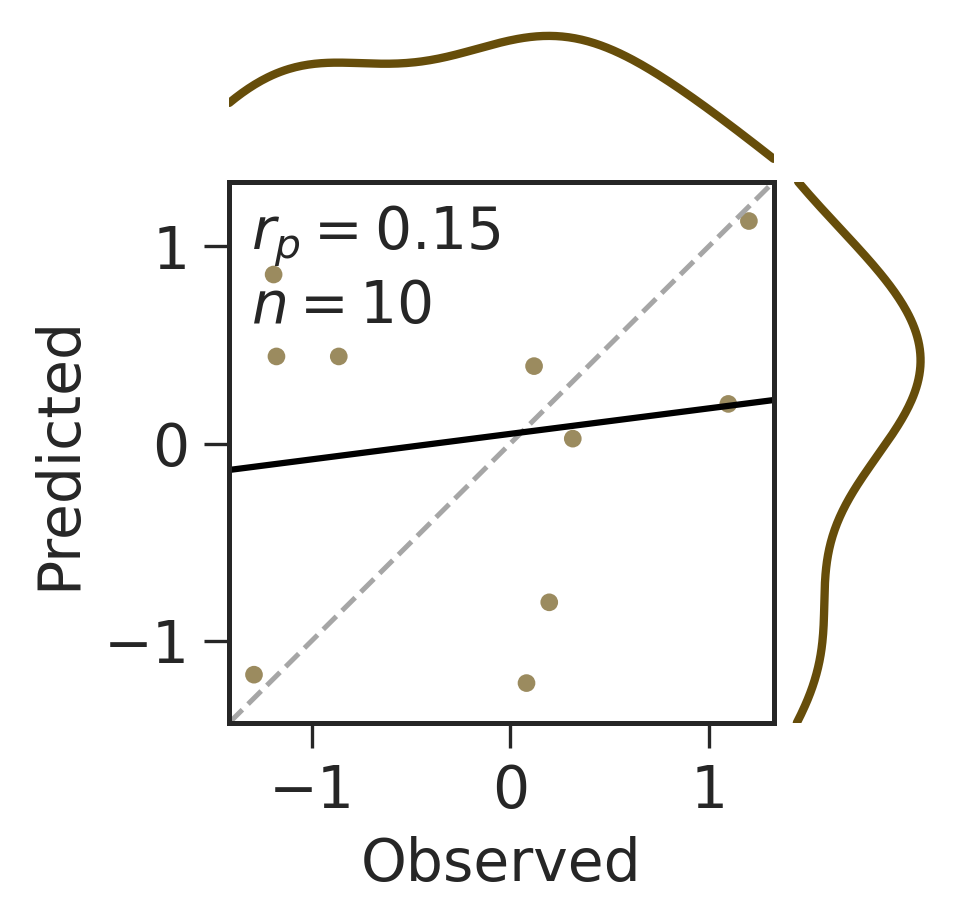

In [26]:
# ============================================
# LightGBM: prediction plot
# ============================================

display(lgbm_metric_df)

fig, axes = joint_scatter(
    y_test,
    pred_y_test_lgbm,
    color="#664D0AFF",
    xlabel="Observed",
    ylabel="Predicted",
    figsize=(3, 3),
)

plt.show()
plt.close()

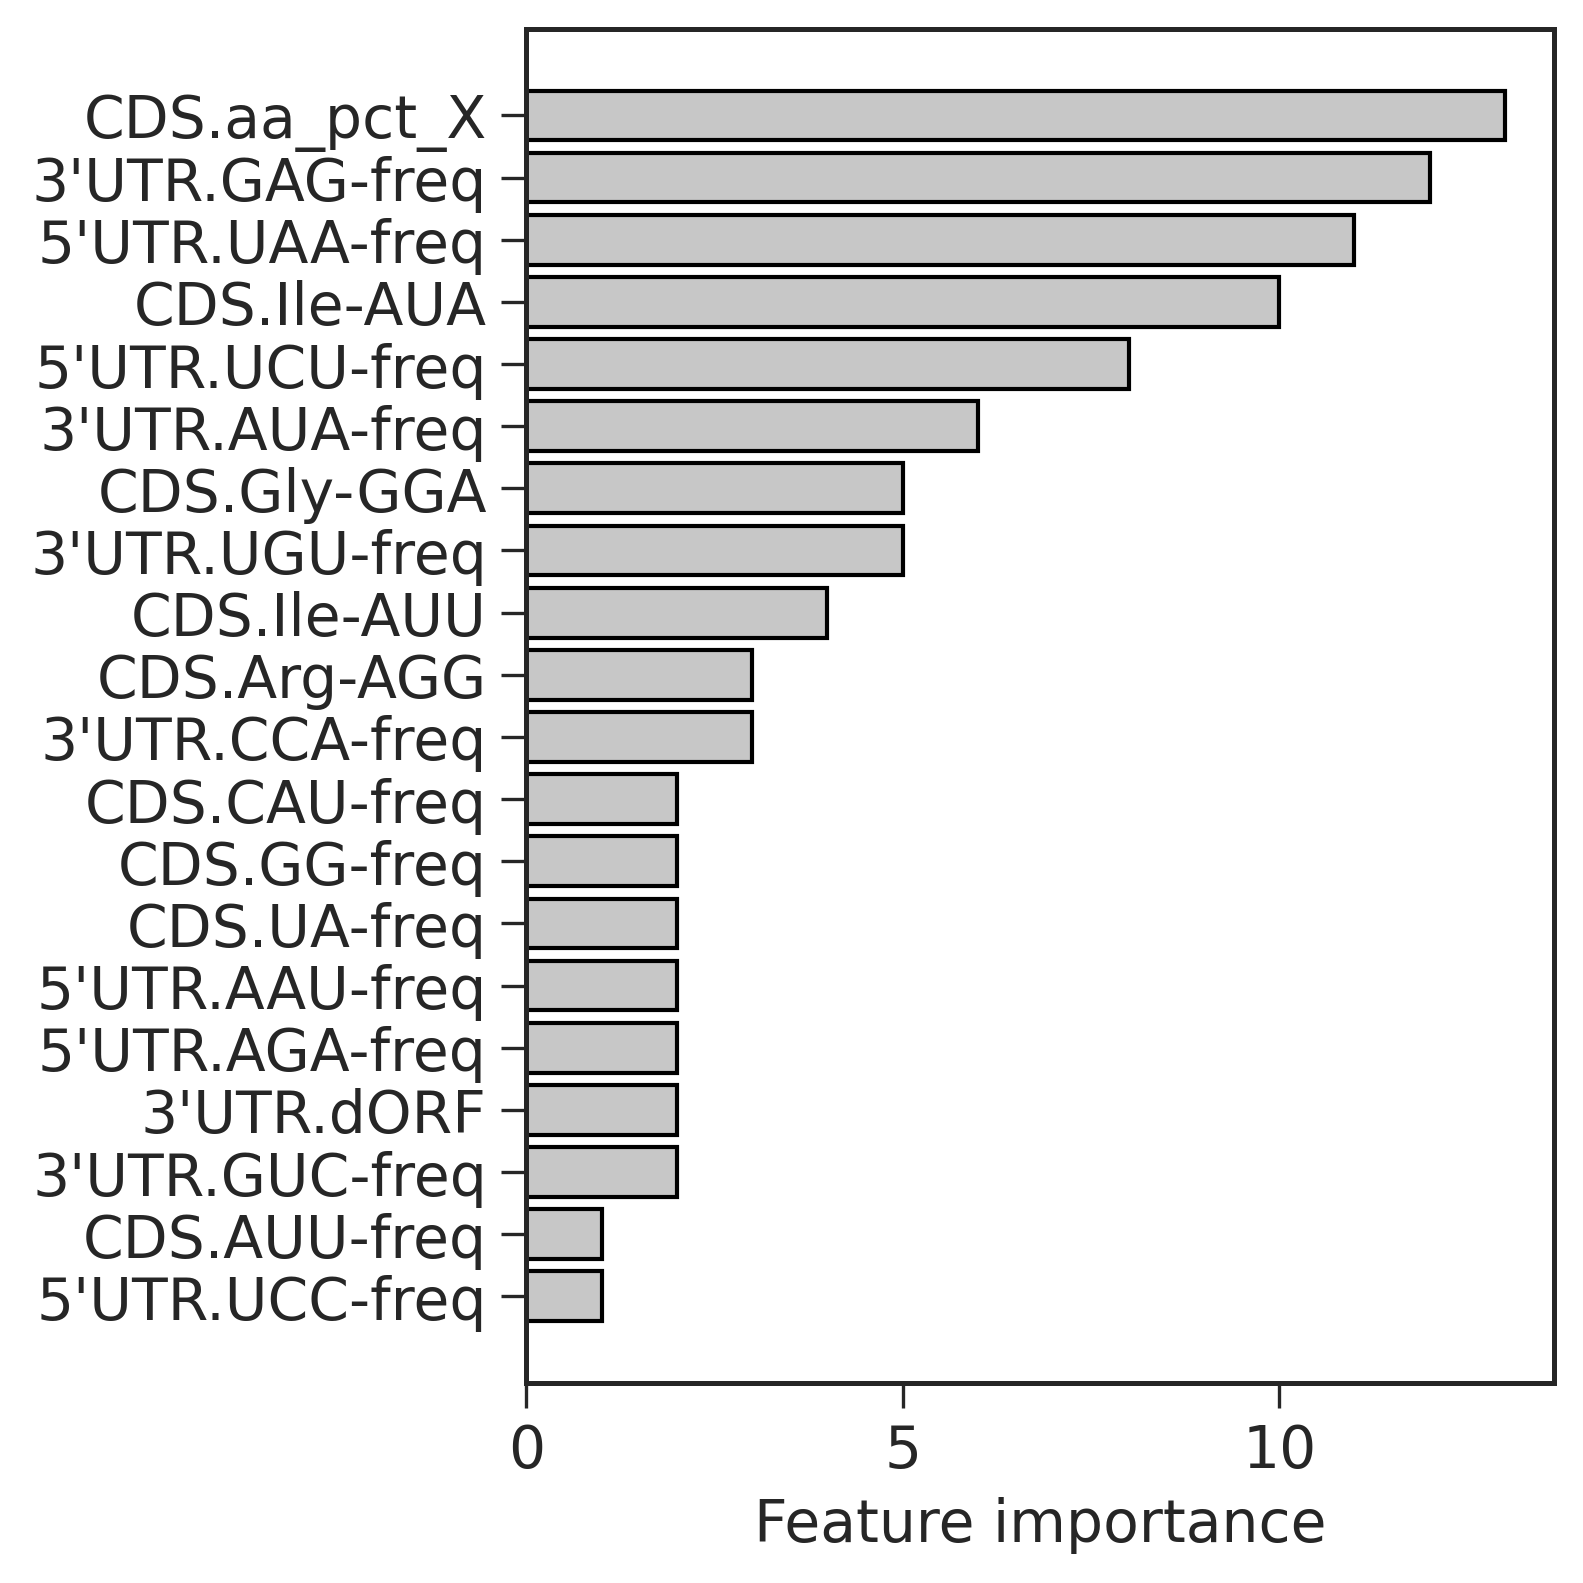

In [22]:
# ---- config ----
TOPK_IMP    = 20          
imp_vals = np.nan_to_num(
    np.asarray(model_lgbm.feature_importances_, dtype=float)
)
feat_importance_lgbm_df = pd.DataFrame(
    {"feature": x_train.columns, "importance": imp_vals}
)
feat_importance_lgbm_df = feat_importance_lgbm_df[
    feat_importance_lgbm_df["importance"] > 0
].copy()

# sort by importance
feat_importance_lgbm_df.sort_values(
    "importance",
    ascending=False,
    inplace=True
)
feat_importance_lgbm_df.reset_index(drop=True, inplace=True)
top_df = feat_importance_lgbm_df.head(
    TOPK_IMP if TOPK_IMP is not None else len(feat_importance_lgbm_df)
).iloc[::-1].copy()

fig, ax = make_fig(w=5.5, h=5.5)   

bars = ax.barh(
    top_df["feature"],
    top_df["importance"].to_numpy(dtype=float),
    edgecolor="#000000",
    color="#C7C7C7"
)
format_axis(
    ax,
    xlabel="Feature importance",
    ylabel=None,
    compact_ticks=()
)

plt.tight_layout()
plt.show()
plt.close()

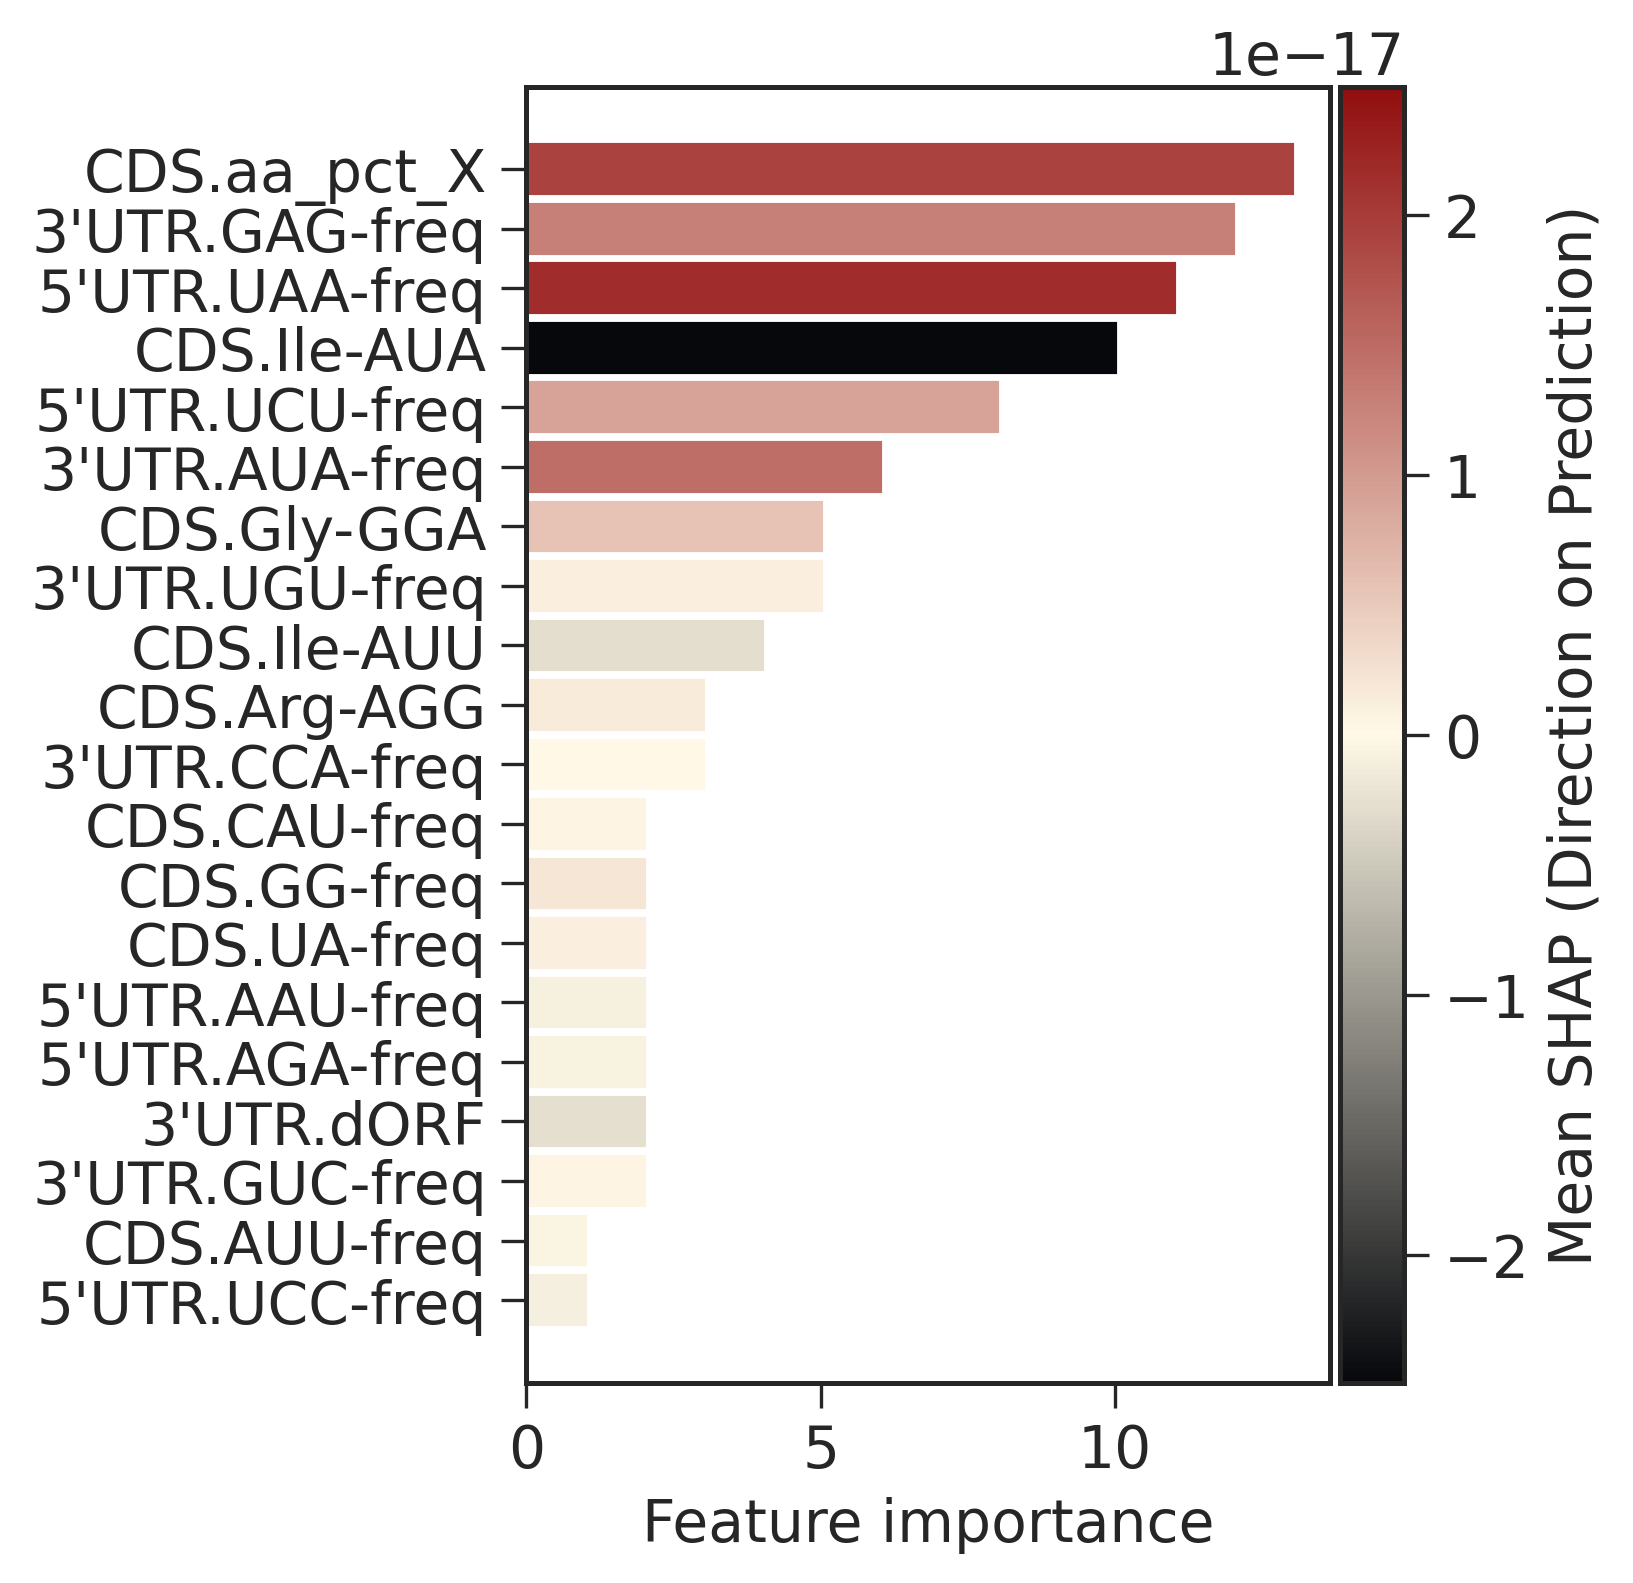

In [23]:
# ---- config ----
TOPK_IMP    = 20          
DrDb = LinearSegmentedColormap.from_list(
    "DrDb",
    ["#06080c", "#FFF9E7", "#910e0eff"]
)

# ------------------------------------------------
# 1) Importance dataframe from model_lgbm
# ------------------------------------------------
imp_vals = np.nan_to_num(
    np.asarray(model_lgbm.feature_importances_, dtype=float)
)

feat_importance_lgbm_df = pd.DataFrame(
    {"feature": x_train.columns, "importance": imp_vals}
)

feat_importance_lgbm_df = (
    feat_importance_lgbm_df[feat_importance_lgbm_df["importance"] > 0]
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------
# 2) Compute mean SHAP per feature (directional)
# ------------------------------------------------
explainer = shap.TreeExplainer(model_lgbm)
shap_vals = explainer.shap_values(x_train)     # shape = (N, F)

mean_shap = shap_vals.mean(axis=0)             # directional
mean_abs_shap = np.abs(shap_vals).mean(axis=0) # optional: magnitude only

# ------------------------------------------------
# 3) Select top-K features and reverse for barh style
# ------------------------------------------------
top_df = feat_importance_lgbm_df.head(TOPK_IMP).iloc[::-1].copy()
top_df["mean_shap"] = [mean_shap[x_train.columns.get_loc(f)] 
                       for f in top_df["feature"]]

# symmetric norm around 0 so color = direction
v = top_df["mean_shap"].to_numpy()
vlim = np.max(np.abs(v)) if np.any(np.isfinite(v)) else 1.0
norm = mpl.colors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)

# ------------------------------------------------
# 4) Plot: bars colored by mean SHAP
# ------------------------------------------------
fig, ax = make_fig(w=5.5, h=5.5)

bars = ax.barh(
    top_df["feature"],
    top_df["importance"].to_numpy(dtype=float),
    edgecolor="none"
)

# Apply SHAP-based colors
for b, shap_v in zip(bars, top_df["mean_shap"].to_numpy()):
    b.set_color(DrDb(norm(shap_v)))

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=DrDb, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Mean SHAP (Direction on Prediction)")

# Axes formatting
format_axis(
    ax,
    xlabel="Feature importance",
    ylabel=None,
    compact_ticks=()
)

plt.tight_layout()
plt.show()
plt.close()


SHAP train shape: (49, 361)
SHAP test shape : (10, 361)

Top 20 features ranked by |SHAP|:


,feature,mean_SHAP,mean_abs_SHAP,SHAP_rank_abs,SHAP_rank_mean
79,5'UTR.UAA-freq,2.152473e-17,0.149906,1.0,2.0
349,CDS.aa_pct_X,1.925897e-17,0.146604,2.0,3.0
225,3'UTR.GAG-freq,1.274491e-17,0.140708,3.0,5.0
295,CDS.Ile-AUA,-2.492337e-17,0.121157,4.0,1.0
195,3'UTR.AUA-freq,1.472745e-17,0.103984,5.0,4.0
289,CDS.Gly-GGA,5.664403e-18,0.096662,6.0,7.0
92,5'UTR.UCU-freq,9.063045e-18,0.075516,7.0,6.0
216,3'UTR.UGU-freq,1.132881e-18,0.058112,8.0,13.0
293,CDS.Ile-AUU,-2.832202e-18,0.055386,9.0,8.0
276,CDS.Arg-AGG,1.416101e-18,0.053568,10.0,11.0


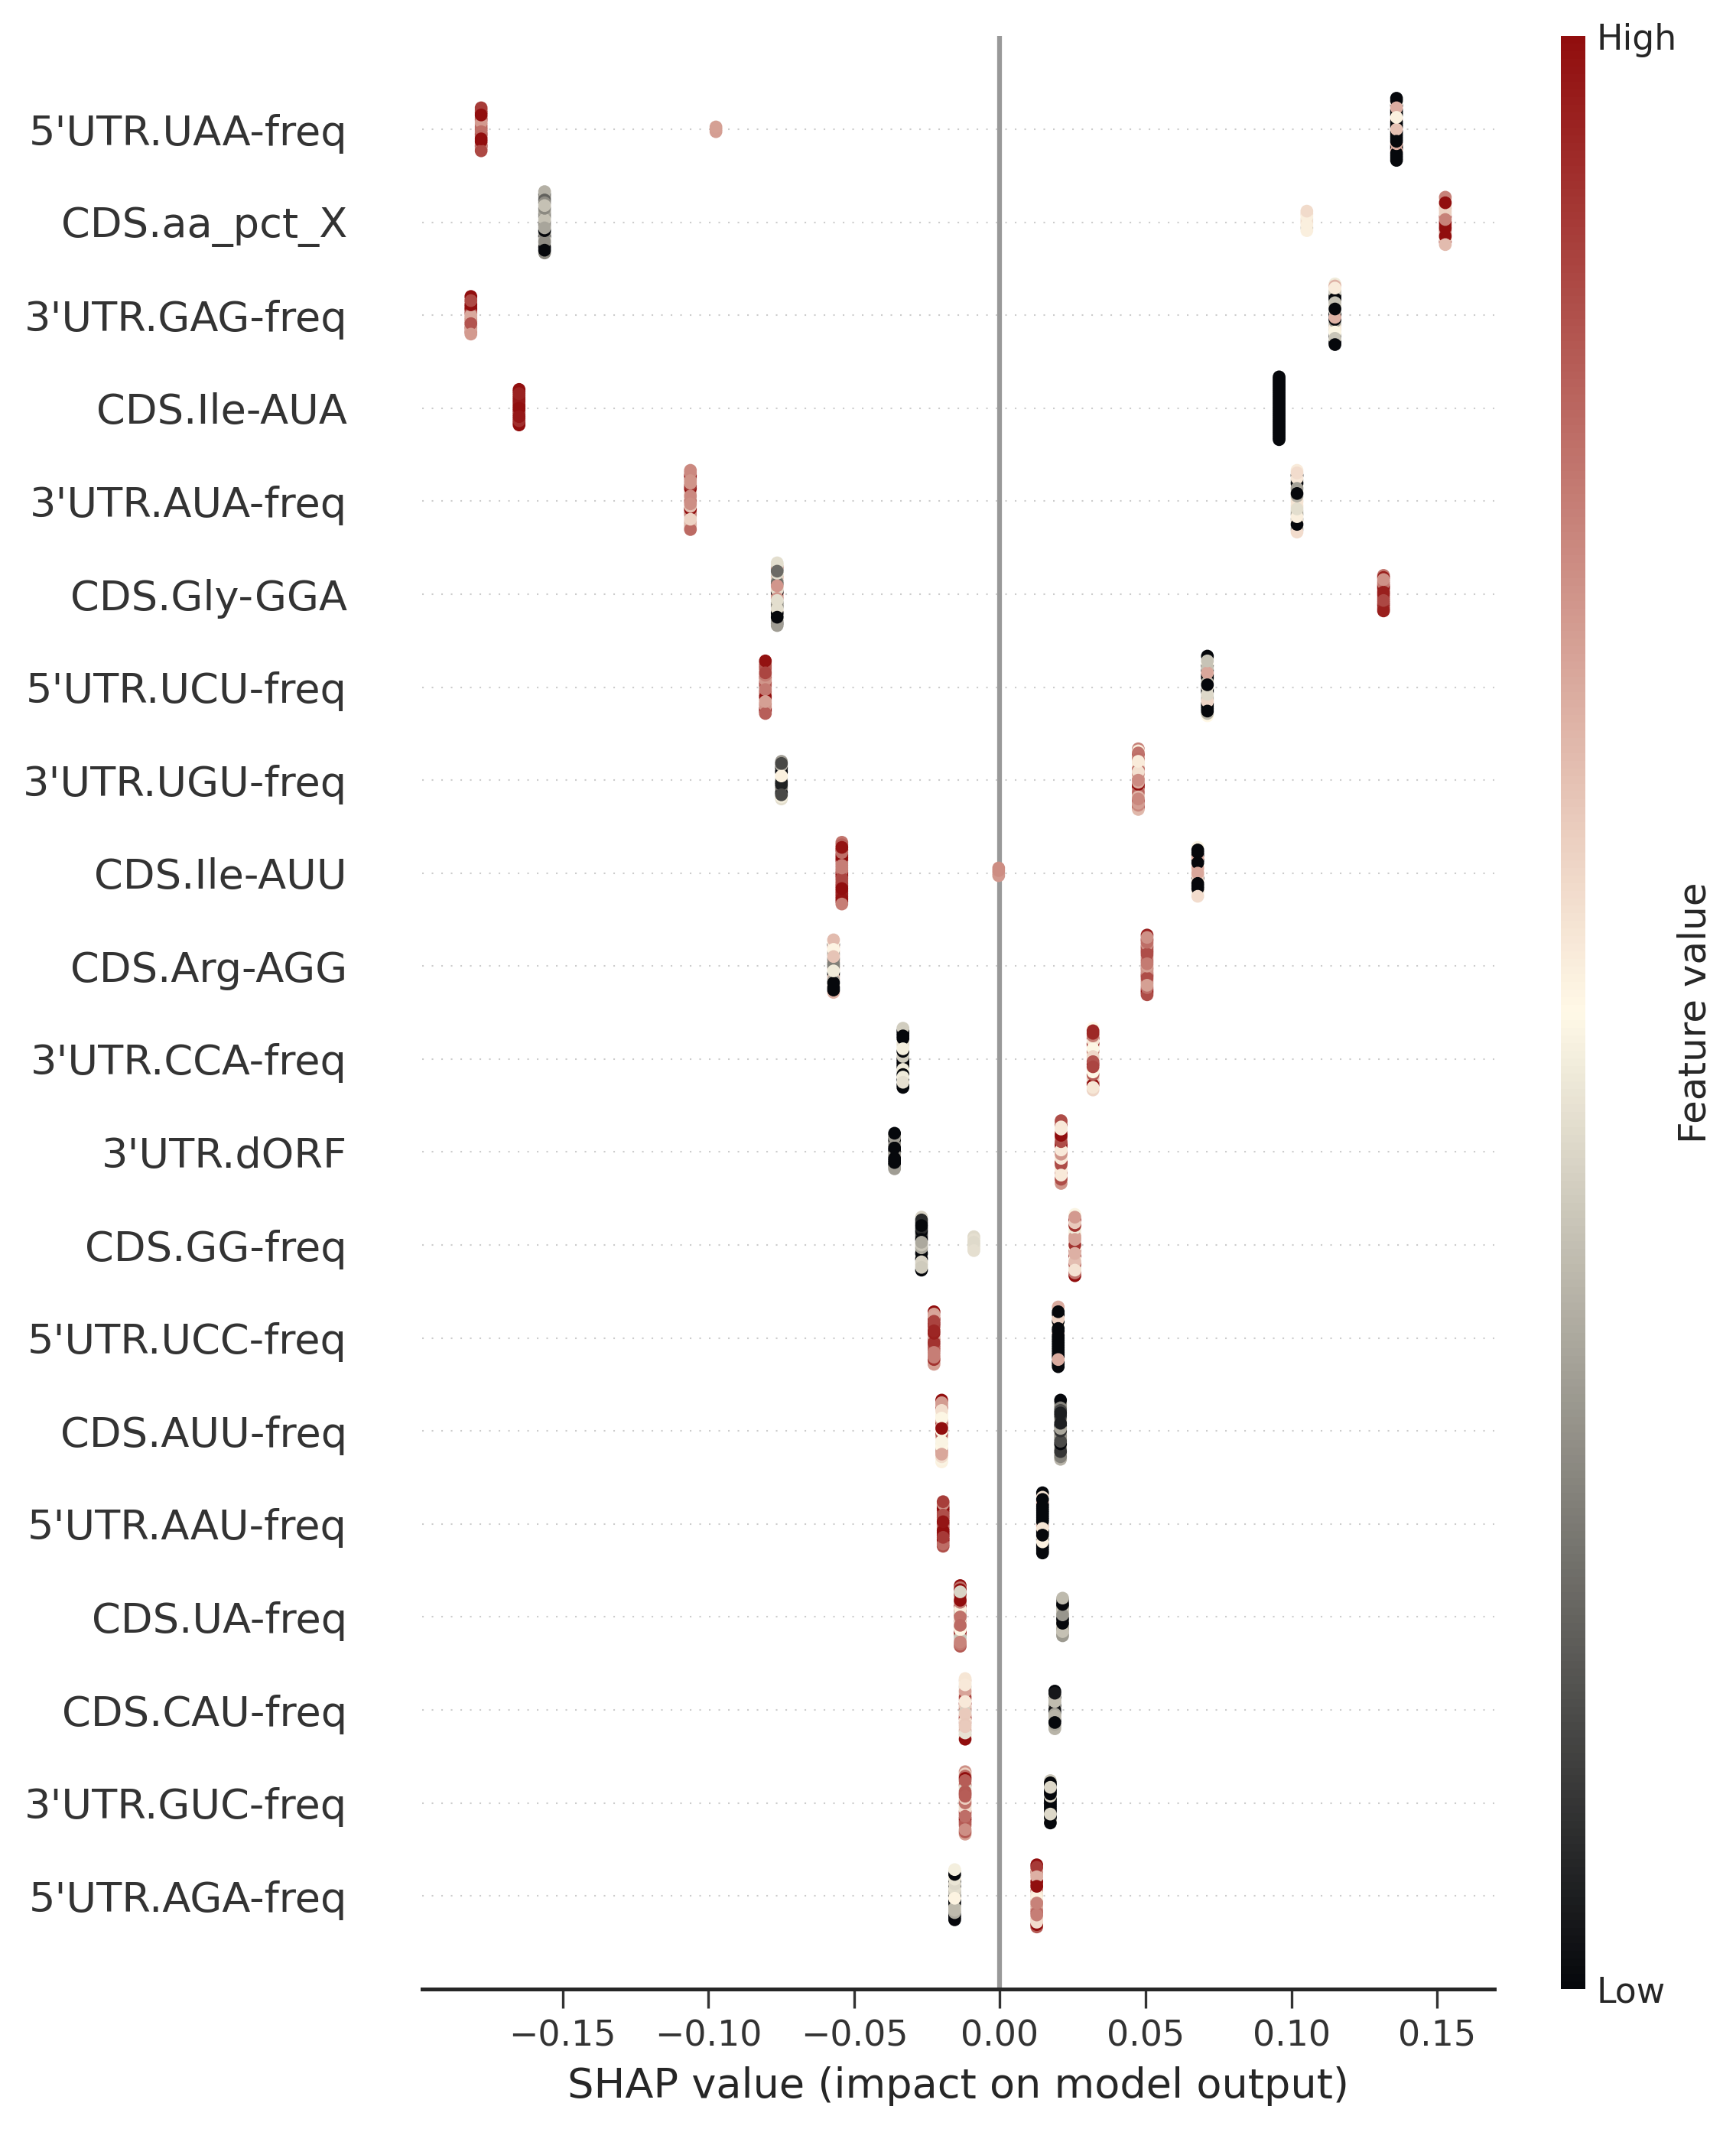

In [24]:
# --------------------------------------------
# 1. SHAP explainer for LightGBM
# --------------------------------------------
explainer = shap.TreeExplainer(model_lgbm)

shap_train_vals = explainer.shap_values(x_train)   # shape = (n_train, n_features)
shap_test_vals  = explainer.shap_values(x_test)    # shape = (n_test,  n_features)

print("SHAP train shape:", shap_train_vals.shape)
print("SHAP test shape :", shap_test_vals.shape)

# Directional effect per feature
mean_shap = shap_train_vals.mean(axis=0)

# Importance magnitude per feature
mean_abs_shap = np.abs(shap_train_vals).mean(axis=0)

# Ranking (lower rank = more important)
shap_rank_abs  = rankdata(-mean_abs_shap, method="average")       # rank by |SHAP|
shap_rank_mean = rankdata(-np.abs(mean_shap), method="average")   # rank by |mean_SHAP|

# Summary dataframe
shap_summary_df = pd.DataFrame({
    "feature": x_train.columns,
    "mean_SHAP": mean_shap,
    "mean_abs_SHAP": mean_abs_shap,
    "SHAP_rank_abs": shap_rank_abs,
    "SHAP_rank_mean": shap_rank_mean,
}).sort_values("SHAP_rank_abs", ascending=True)

print("\nTop 20 features ranked by |SHAP|:")
display(shap_summary_df.head(20))

# Colors picked from your DrDb palette
NEG_COLOR = "#06080c"    # dark (negative effect)
POS_COLOR = "#910e0eff"  # red (positive effect)
ABS_COLOR = "#868686ff"  # single color for |SHAP| bars

def plot_shap_mean_bar_split(
    shap_summary_df,
    top_k=20,
    w=5.0,
    h=None,
):
    """
    Make TWO bar plots:

      (1) Top-k features with positive mean SHAP
      (2) Top-k features with negative mean SHAP

    This avoids mixing directions in one panel.
    """
    df = shap_summary_df.copy()

    # ---- positive features ----
    pos_df = df[df["mean_SHAP"] > 0].copy()
    pos_df = pos_df.reindex(pos_df["mean_SHAP"].sort_values(ascending=False).index)
    pos_df = pos_df.head(top_k)

    if len(pos_df) > 0:
        values = pos_df["mean_SHAP"].to_numpy()[::-1]   # reverse for barh
        feats  = pos_df["feature"].tolist()[::-1]

        if h is None:
            h_pos = 0.3 * len(pos_df) + 1.0
        else:
            h_pos = h

        fig, ax = make_fig(w=w, h=h_pos)
        ax.barh(
            feats,
            values,
            edgecolor="none",
            color=POS_COLOR,
        )
        ax.axvline(0.0, color="0.25", lw=1.0)

        format_axis(
            ax,
            xlabel="Mean SHAP",
            ylabel=None,
            compact_ticks=()
        )

        plt.tight_layout()
        plt.show()
        plt.close()

    # ---- negative features ----
    neg_df = df[df["mean_SHAP"] < 0].copy()
    # sort by strongest negative (most negative) first
    neg_df = neg_df.reindex(neg_df["mean_SHAP"].sort_values(ascending=True).index)
    neg_df = neg_df.head(top_k)

    if len(neg_df) > 0:
        values = neg_df["mean_SHAP"].to_numpy()[::-1]
        feats  = neg_df["feature"].tolist()[::-1]

        if h is None:
            h_neg = 0.3 * len(neg_df) + 1.0
        else:
            h_neg = h

        fig, ax = make_fig(w=w, h=h_neg)
        ax.barh(
            feats,
            values,
            edgecolor="none",
            color=NEG_COLOR,
        )
        ax.axvline(0.0, color="0.25", lw=1.0)

        format_axis(
            ax,
            xlabel="Mean SHAP",
            ylabel=None,
            compact_ticks=()
        )

        plt.tight_layout()
        plt.show()
        plt.close()

def plot_shap_mean_abs_bar(
    shap_summary_df,
    top_k=20,
    w=5,
    h=None,
):
    """
    Single bar plot of mean |SHAP| (non-directional importance).
    All bars use the same color ABS_COLOR.
    """
    df = shap_summary_df.copy()
    df = df.sort_values("mean_abs_SHAP", ascending=False)
    df = df.head(top_k).iloc[::-1].copy()

    values = df["mean_abs_SHAP"].to_numpy()
    feats  = df["feature"].tolist()

    if h is None:
        h = 0.3 * len(df) + 1.0

    fig, ax = make_fig(w=w, h=h)

    ax.barh(
        feats,
        values,
        edgecolor="none",
        color=ABS_COLOR,
    )

    format_axis(
        ax,
        xlabel="Mean |SHAP|",
        ylabel=None,
        compact_ticks=()
    )

    plt.tight_layout()
    plt.show()
    plt.close()


# --------------------------------------------
# Plot mean SHAP bars (directional + |SHAP|)
# --------------------------------------------
# plot_shap_mean_abs_bar(shap_summary_df, top_k=20)
# # two panels: positive-only and negative-only
# plot_shap_mean_bar_split(shap_summary_df, top_k=20)

# --------------------------------------------
# Sanity-check: SHAP beeswarm
# --------------------------------------------

try:
    shap.summary_plot(
        shap_train_vals,
        x_train,
        max_display=20,
        cmap=DrDb,
        show=True     
    )

    plt.show()
    plt.close()
except Exception as e:
    print("[Warning] SHAP summary_plot failed:", e)



In [ ]:
# # ------------------------------------------------
# # 1) Grouping by Region
# # ------------------------------------------------

# all_cols = x_train.columns

# misc_prefixes = ("5'UTR-CDS", "CDS-3'UTR", "Kozak", "Stop")

# misc_cols = [c for c in all_cols if c.startswith(misc_prefixes)]

# utr5_cols = [
#     c for c in all_cols
#     if c.startswith("5'UTR") and not c.startswith("5'UTR-CDS")
# ]

# cds_cols = [
#     c for c in all_cols
#     if c.startswith("CDS") and not c.startswith("CDS-3'UTR")
# ]

# utr3_cols = [
#     c for c in all_cols
#     if c.startswith("3'UTR")
# ]

# region_groups = {
#     "5'UTR": utr5_cols,
#     "CDS":   cds_cols,
#     "3'UTR": utr3_cols,
#     "Misc":  misc_cols,
# }

# print("Region groups:")
# tot = 0
# for k, v in region_groups.items():
#     print(f"  {k}: {len(v)} features")
#     tot += len(v)
# print("Total counted:", tot)
# print("x_train.shape[1]:", x_train.shape[1])
# print("="*50)
# # ------------------------------------------------
# # 2) Grouping by Feature Type
# # ------------------------------------------------
# def feature_subgroup(col: str) -> str:
#     if col.endswith(".Length"):
#         return "Length"

#     if (
#         re.search(r"\.[AUGCTU]+-freq\d?$", col)
#         or col.endswith(".S-freq")
#         or col.endswith(".Y-freq")
#         or col.endswith(".K-freq")
#     ):
#         return "Nucleotide_Freqs"

#     if (
#         ".uAUG" in col or ".uATG" in col or
#         ".uORF" in col or
#         ".dAUG" in col or ".dATG" in col or
#         ".dORF" in col
#     ):
#         return "ORF_nonCDS"

#     if (
#         ".MFE" in col
#         or ".BPP" in col
#         or ".stem_" in col
#         or col.endswith(".nBP")
#     ):
#         return "RNA_Structure"

#     if col.endswith(".PWM") or col == "Kozak.strength":
#         return "PWM"

#     if (
#         ".aa_pct_" in col or
#         ".wobble_pct_" in col or
#         ".dicodon_" in col or
#         re.search(r"\.[A-Z][a-z]{2}-[AUGC]{3}$", col)
#     ):
#         return "Coding_Composition"

#     return "Other"

# sub_feature_groups = {}
# for c in x_train.columns:   
#     g = feature_subgroup(c)
#     sub_feature_groups.setdefault(g, []).append(c)

# print("Subgroups:")
# tot = 0
# for k, v in sub_feature_groups.items():
#     print(f"  {k}: {len(v)} features")
#     tot += len(v)
# print("Total cols:", tot)
# print("x_train.shape[1]:", x_train.shape[1])


Region groups:
  5'UTR: 98 features
  CDS: 190 features
  3'UTR: 97 features
  Misc: 15 features
Total counted: 400
x_train.shape[1]: 400
Subgroups:
  Length: 3 features
  Nucleotide_Freqs: 258 features
  ORF_nonCDS: 7 features
  Coding_Composition: 104 features
  RNA_Structure: 23 features
  PWM: 5 features
Total cols: 400
x_train.shape[1]: 400


In [ ]:
# def make_proto_lgbm():
#     return LGBMRegressor(
#         objective="regression",
#         n_estimators=n_estimators,
#         learning_rate=fixed_learning_rate,
#         n_jobs=n_jobs,
#         random_state=0,
#         **best_params_lgbm,
#     )

# def score_group_combos(group_dict, X_train, y_train, groups_train=None,
#                        k_folds=5, random_state=0):
#     filtered = {
#         g: [c for c in cols if c in X_train.columns]
#         for g, cols in group_dict.items()
#     }
#     filtered = {g: cols for g, cols in filtered.items() if len(cols) > 0}

#     group_names = list(filtered.keys())
#     y_arr = np.asarray(y_train)

#     rows = []

#     for k in range(1, len(group_names) + 1):
#         for comb in itertools.combinations(group_names, k):
#             cols = list(itertools.chain.from_iterable(filtered[g] for g in comb))
#             if not cols:
#                 continue

#             Xt = X_train[cols]

#             # choose splitter based on groups_train
#             if groups_train is None:
#                 splitter = KFold(n_splits=k_folds, shuffle=True, random_state=random_state)
#                 split_iter = splitter.split(Xt, y_arr)
#             else:
#                 splitter = GroupKFold(n_splits=k_folds)
#                 split_iter = splitter.split(Xt, y_arr, groups_train)

#             fold_scores = []
#             for tr_idx, va_idx in split_iter:
#                 Xtr, Xva = Xt.iloc[tr_idx], Xt.iloc[va_idx]
#                 ytr, yva = y_arr[tr_idx], y_arr[va_idx]

#                 m = make_proto_lgbm()
#                 m.fit(Xtr, ytr)
#                 yhat = m.predict(Xva)
#                 fold_scores.append(r2_score(yva, yhat))

#             rows.append({
#                 "combo": "+".join(comb),
#                 "sets": list(comb),
#                 "mean_R2": float(np.mean(fold_scores)),
#                 "n_sets": len(comb),
#             })

#     df = (pd.DataFrame(rows)
#           .sort_values(["n_sets", "mean_R2"], ascending=[True, False])
#           .reset_index(drop=True))
#     return df


In [ ]:
# cv_region_df = score_group_combos(
#     region_groups,  
#     x_train,
#     y_train,
#     groups_train=g_train if group_col_name is not None else None,
#     k_folds=k_cv,
# )
# display(cv_region_df)
# print("="*50)
# cv_type_df = score_group_combos(
#     sub_feature_groups,
#     x_train,
#     y_train,
#     groups_train=g_train if group_col_name is not None else None,
#     k_folds=k_cv,
# )
# display(cv_type_df.head(10))

[LightGBM] [Warning] feature_fraction is set=0.2, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2
[LightGBM] [Warning] feature_fraction is set=0.2, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19900
[LightGBM] [Info] Number of data points in the train set: 5128, number of used features: 97
[LightGBM] [Info] Start training from score 0.001382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

,combo,sets,mean_R2,n_sets
0,5'UTR,[5'UTR],0.223825,1
1,CDS,[CDS],0.213977,1
2,Misc,[Misc],0.193165,1
3,3'UTR,[3'UTR],0.174050,1
4,5'UTR+CDS,"[5'UTR, CDS]",0.253406,2
5,5'UTR+Misc,"[5'UTR, Misc]",0.236344,2
6,5'UTR+3'UTR,"[5'UTR, 3'UTR]",0.228100,2
7,CDS+Misc,"[CDS, Misc]",0.224545,2
8,CDS+3'UTR,"[CDS, 3'UTR]",0.215611,2
9,3'UTR+Misc,"[3'UTR, Misc]",0.201679,2


[LightGBM] [Warning] feature_fraction is set=0.2, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2
[LightGBM] [Warning] feature_fraction is set=0.2, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000041 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 662
[LightGBM] [Info] Number of data points in the train set: 5128, number of used features: 3
[LightGBM] [Info] Start training from score 0.001382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

,combo,sets,mean_R2,n_sets
0,Nucleotide_Freqs,[Nucleotide_Freqs],0.249986,1
1,Coding_Composition,[Coding_Composition],0.219944,1
2,RNA_Structure,[RNA_Structure],0.207377,1
3,Length,[Length],0.063799,1
4,PWM,[PWM],0.062556,1
5,ORF_nonCDS,[ORF_nonCDS],0.007993,1
6,Nucleotide_Freqs+RNA_Structure,"[Nucleotide_Freqs, RNA_Structure]",0.251332,2
7,Nucleotide_Freqs+PWM,"[Nucleotide_Freqs, PWM]",0.249969,2
8,Nucleotide_Freqs+Coding_Composition,"[Nucleotide_Freqs, Coding_Composition]",0.249262,2
9,Length+Nucleotide_Freqs,"[Length, Nucleotide_Freqs]",0.249025,2


In [ ]:
# def plot_upset_from_cv(
#     cv_df,
#     group_dict,
#     selected_groups=None,
#     title="",
#     facecolor="#000000",
#     fig_w=7.5,
#     fig_h=3.6,
#     dpi=300,
#     min_single_r2_for_combos=None,   # threshold for singles entering combos
#     min_combo_r2=None,               # optional threshold on combo mean_R2
# ):
#     """
#     Make an UpSet-style plot where subset size = mean R² (CV).

#     cv_df: DataFrame from score_group_combos()
#            columns: 'combo', 'sets' (list of group names), 'mean_R2', 'n_sets'
#     group_dict: {group_name: [feature_cols, ...]}
#     selected_groups: list of group names to include (if None → all keys)
#     """

#     # ---- which groups are we showing? ----
#     if selected_groups is None:
#         selected_groups = list(group_dict.keys())
#     else:
#         selected_groups = [g for g in selected_groups if g in group_dict]

#     if not selected_groups:
#         print("[UpSet] No selected_groups present in group_dict.")
#         return None

#     selected_set = set(selected_groups)

#     # ---- gather singleton mean R² (for filtering combos) ----
#     single_r2 = {}  # group → mean_R2
#     singles = cv_df[cv_df["n_sets"] == 1]
#     for _, row in singles.iterrows():
#         sets = list(row["sets"])
#         if len(sets) != 1:
#             continue
#         g = sets[0]
#         if g not in selected_set:
#             continue
#         r2 = float(row["mean_R2"])
#         # if there are duplicates, keep the best singleton score
#         single_r2[g] = max(single_r2.get(g, -np.inf), r2)

#     # ---- build memberships + values ----
#     memberships = []
#     vals = []

#     for _, row in cv_df.iterrows():
#         sets = list(row["sets"])
#         if len(sets) == 0:
#             continue
#         if not set(sets).issubset(selected_set):
#             continue

#         r2 = float(row["mean_R2"])

#         # Singles are *always* kept (we use them as indicators)
#         if len(sets) == 1:
#             memberships.append(sets)
#             vals.append(r2)
#             continue

#         # For multi-group combos, apply thresholds
#         if min_single_r2_for_combos is not None:
#             ok_all_singles = all(
#                 single_r2.get(g, -np.inf) >= min_single_r2_for_combos
#                 for g in sets
#             )
#             if not ok_all_singles:
#                 continue

#         if min_combo_r2 is not None and r2 < min_combo_r2:
#             continue

#         memberships.append(sets)
#         vals.append(r2)

#     if not memberships:
#         print("[UpSet] No combos left after applying filters.")
#         return None

#     # ---- UpSet data: membership → mean R² ----
#     series = from_memberships(memberships, data=vals)
#     levels = list(range(series.index.nlevels))
#     series_unique = series.groupby(level=levels).mean()

#     up = UpSet(
#         series_unique,
#         show_counts=False,
#         subset_size="sum",
#         sort_categories_by=None,
#         facecolor=facecolor,
#         element_size=23,
#     )

#     fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi, facecolor="white")
#     up.plot(fig=fig)

#     # ---- remove left "totals" bar axis (vertical bar over labels) ----
#     bar_axes = [
#         ax for ax in fig.axes
#         if any(isinstance(c, mpl.container.BarContainer) for c in ax.containers)
#     ]
#     if bar_axes:
#         top_bar = max(bar_axes, key=lambda a: a.get_position().y0)
#         left_totals = min(
#             (ax for ax in bar_axes if ax is not top_bar),
#             key=lambda a: a.get_position().x0,
#             default=None,
#         )
#         if left_totals is not None:
#             left_totals.remove()

#     # ---- matrix axis: clean spines, relabel with n-features ----
#     matrix_axes = [
#         ax for ax in fig.axes
#         if any(getattr(coll, "get_offsets", None) for coll in ax.collections)
#     ]
#     if matrix_axes:
#         ax_matrix = matrix_axes[0]
#         ax_matrix.spines["left"].set_visible(False)
#         ax_matrix.spines["right"].set_visible(False)
#         ax_matrix.tick_params(axis="y", pad=1)

#         label_map = {
#             g: f"{g} (n={len(group_dict.get(g, []))})"
#             for g in selected_groups
#         }
#         old_labels = [t.get_text() for t in ax_matrix.get_yticklabels()]
#         new_labels = [label_map.get(lbl, lbl) for lbl in old_labels]
#         ax_matrix.set_yticklabels(new_labels)

#     # ---- y-label for top bar chart ----
#     for ax in fig.axes:
#         if ax.get_ylabel() == "Intersection size":
#             ax.set_ylabel("Mean $R^2$ (CV)", labelpad=6)
#             break

#     if title:
#         fig.suptitle(title, y=1.02)

#     try:
#         fig.subplots_adjust(left=0.28)
#     except Exception:
#         pass

#     plt.tight_layout()
#     plt.show()
#     return fig



Group by Region Type


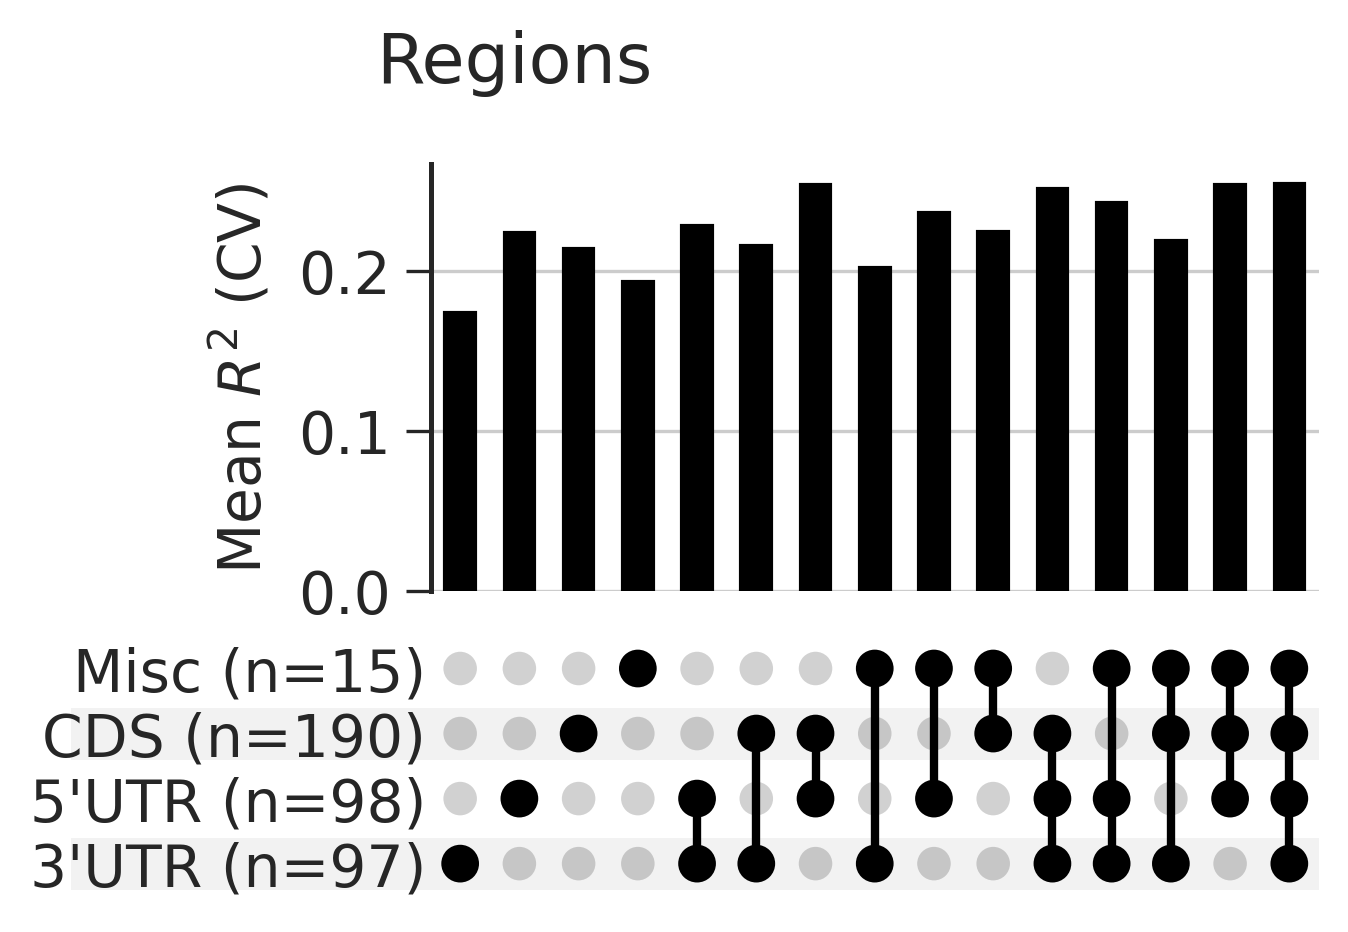


Group by Feature Type


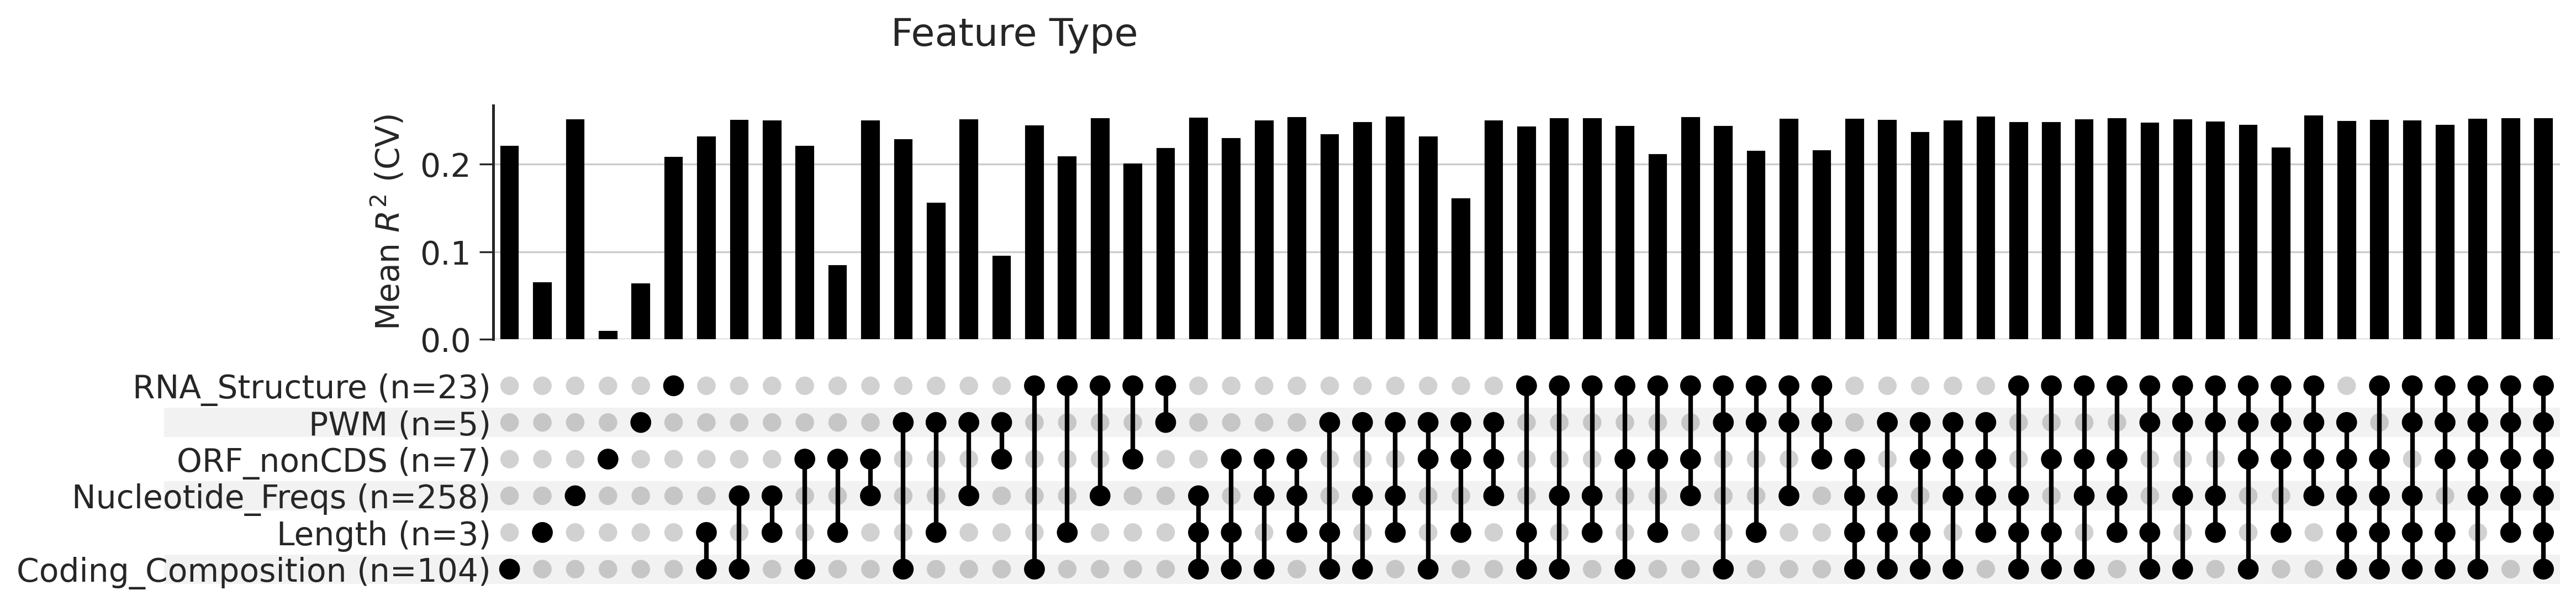

In [ ]:
# # Regions: 5'UTR, CDS, 3'UTR, Misc
# print("="*50,"\n\nGroup by Region Type")
# region_present = [g for g in region_groups if len(region_groups[g]) > 0]

# fig_region = plot_upset_from_cv(
#     cv_region_df,
#     region_groups,
#     selected_groups=region_present,
#     title="Regions",
#     facecolor="#000000",
#     fig_w=8,
#     fig_h=6,
#     min_single_r2_for_combos=None,   
#     min_combo_r2=0,               
# )
# print("="*50,"\n\nGroup by Feature Type")

# subgroups_present = [g for g in sub_feature_groups if len(sub_feature_groups[g]) > 0]

# fig_type = plot_upset_from_cv(
#     cv_type_df,
#     sub_feature_groups,
#     selected_groups=subgroups_present,
#     title="Feature Type",
#     facecolor="#000000",
#     fig_w=8,
#     fig_h=5,
#     min_single_r2_for_combos=0
# )
